# Phase 3 Step 5a — 02a Stockwise 단독 평가 (`05a_eval_stockwise.ipynb`)

> **목적**: 02a 종목별 ensemble (Stockwise LSTM + HAR) 의 변동성 예측 + BL_ml_sw 포트폴리오 성과를
>          **다른 모델·시나리오와 비교 없이 단독으로** 평가한다.
>          비교는 별도 노트북 (`05c_eval_compare.ipynb`) 에서 수행.

## 평가 4 레이어

| § | Layer | 내용 |
|---|---|---|
| §2 | **Layer 1** | 변동성 예측 진단 (RMSE/QLIKE/MZ/DM-test/Best model) |
| §3 | **Layer 2** | BL_ml_sw 포트폴리오 단독 (Sharpe/CAPM α/IR/Sortino/CVaR/turnover) |
| §4 | **Layer 3** | ML → BL 인과 추적 (low/high vol hit rate, P 행렬 안정성) |
| §5 | **Layer 4** | 시기별 분해 (5 시기 × 모든 메트릭) |
| §6 | 종합 요약 | render_diagnostic_summary 자동 생성 |

## 평가 모듈 (`scripts/diagnostics.py`)
모든 평가 함수는 모듈에 정의됨 → 호출만 수행 → **05b/05c 와 동일 형식 보장**.

## 사전 조건
- ✅ `data/ensemble_predictions_stockwise.csv` (02a 결과)
- ✅ `data/daily_panel.csv`
- ✅ `outputs/03_bl_backtest/returns_BL_ml_sw.csv` (03 결과)
- 🔵 02a 학습 진행 중에도 본 노트북 코드 작성·검증 가능 (실행은 결과 가용 후)


## §1. 환경 부트스트랩 + 결과 로드

In [99]:
%load_ext autoreload
%autoreload 2

import sys, json, warnings
warnings.filterwarnings('ignore')
from pathlib import Path

NB_DIR = Path.cwd()
if str(NB_DIR) not in sys.path:
    sys.path.insert(0, str(NB_DIR))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scripts.setup import bootstrap, DATA_DIR, OUTPUTS_DIR
import scripts.diagnostics as diag

font_used = bootstrap()

OUT_DIR = OUTPUTS_DIR / '05a_v2_eval_stockwise'  # Phase 3-2 v2
OUT_DIR.mkdir(parents=True, exist_ok=True)
print(f'OUT_DIR: {OUT_DIR}')

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
  Phase 3 Robust Extensions — 환경 부트스트랩 완료
  한글 폰트   : Malgun Gothic
  시드        : 42
  데이터 경로  : C:\Users\gorhk\최종 프로젝트\finance_project\시계열_Test\Phase3_Robust_Extensions\data
  Phase 1.5  : C:\Users\gorhk\최종 프로젝트\finance_project\시계열_Test\Phase1_5_Volatility
  Phase 2    : C:\Users\gorhk\최종 프로젝트\finance_project\시계열_Test\Phase2_BL_Integration
OUT_DIR: C:\Users\gorhk\최종 프로젝트\finance_project\시계열_Test\Phase3_Robust_Extensions\outputs\05a_eval_stockwise


In [100]:
# 02a 결과 로드
ens_sw_path = DATA_DIR / 'ensemble_predictions_stockwise.csv'
assert ens_sw_path.exists(), f'02a 결과 없음: {ens_sw_path}'
ens_sw = pd.read_csv(ens_sw_path, parse_dates=['date'])
print(f'ensemble_sw: {ens_sw.shape}')
print(f'  unique 종목: {ens_sw["ticker"].nunique()}')
print(f'  날짜 범위: {ens_sw["date"].min().date()} ~ {ens_sw["date"].max().date()}')
print(f'  컬럼: {list(ens_sw.columns)}')

ensemble_sw: (2468770, 9)
  unique 종목: 613
  날짜 범위: 2007-04-23 ~ 2025-12-01
  컬럼: ['date', 'ticker', 'fold', 'y_true', 'y_pred_lstm', 'y_pred_har', 'w_v4', 'w_har', 'y_pred_ensemble']


In [101]:
# Daily panel (vol_21d 비교용)
panel = pd.read_csv(
    DATA_DIR / 'daily_panel.csv', parse_dates=['date'],
    usecols=['date', 'ticker', 'vol_21d', 'log_ret', 'log_mcap', 'spy_close'],
)
print(f'panel: {panel.shape}')

# Market data
market = pd.read_csv(DATA_DIR / 'market_data.csv', index_col='date', parse_dates=True)
# ⭐ Issue #1 패턴 fix (2026-04-30): BL_ml_sw 와 동일 거래일 월말 정렬
#   기존 calendar 월말 (resample 'ME') 은 BL returns index (거래일 월말) 와
#   1일 차이로 ~30% mismatch → SPY 누적이 11.23배 → 5.82배 로 잘못 표시되던 문제 fix
# Phase 3-2 v2: OOS 2010-2024 + 2025 hold-out 분리
OOS_START = '2010-01-01'
OOS_END = '2024-12-31'
HOLDOUT_START = '2025-01-01'
HOLDOUT_END = '2025-12-31'
_reb_all = market.groupby(market.index.to_period('M')).tail(1).index
oos_dates = _reb_all[(_reb_all >= OOS_START) & (_reb_all <= OOS_END)]
holdout_dates = _reb_all[(_reb_all >= HOLDOUT_START) & (_reb_all <= HOLDOUT_END)]
reb_dates_for_spy = pd.DatetimeIndex(list(oos_dates) + list(holdout_dates))
spy_monthly = market['SPY'].reindex(reb_dates_for_spy, method='ffill').pct_change().dropna()
print(f'spy_monthly (Phase 3-2): {len(spy_monthly)} 개월 (OOS {len(oos_dates)} + hold-out {len(holdout_dates)})')

panel: (3344502, 6)
spy_monthly: 203 개월 (거래일 월말 기준, BL_ml_sw 와 일관)


In [102]:
# BL_ml_sw 포트폴리오 결과 로드
# ⭐ Step 1 (2026-04-30): 03 BL 미실행 (02b 학습 중) 시 02a §6 sanity check 캐시 fallback
# 02b 학습에 영향 0 보장 — 본 셀은 02b 가 사용하지 않는 데이터만 읽음
import pickle


def make_returns_manual(weights_dict, name, forward_rets):
    """02a §6-3 일관: weights → portfolio returns 직접 계산.
    backtest_strategy 우회 (Issue 5).
    """
    if not weights_dict:
        return pd.Series(dtype=float, name=name)
    rets, dates = [], []
    for reb_date in sorted(weights_dict.keys()):
        w = weights_dict[reb_date]
        if reb_date not in forward_rets.index:
            continue
        r_next = forward_rets.loc[reb_date]
        common_t = w.index.intersection(r_next.index)
        if len(common_t) == 0:
            continue
        w_c = w.reindex(common_t).fillna(0)
        r_c = r_next.reindex(common_t).fillna(0)
        port_ret = float((w_c * r_c).sum())
        rets.append(port_ret)
        dates.append(reb_date)
    if not rets:
        return pd.Series(dtype=float, name=name)
    return pd.Series(rets, index=pd.DatetimeIndex(dates), name=name)


bl_returns_path = OUTPUTS_DIR / '03_bl_backtest' / 'returns_BL_ml_sw.csv'
bl_cache_path = DATA_DIR / 'bl_weights_v2_sanity_check.pkl'  # Phase 3-2 v2

if bl_returns_path.exists():
    # 우선: 03 정식 BL 백테스트 결과
    bl_ml_sw_returns = pd.read_csv(
        bl_returns_path, index_col=0, parse_dates=True
    ).squeeze()
    print(f'BL_ml_sw returns (03 정식): {len(bl_ml_sw_returns)} 개월')
    print(f'  기간: {bl_ml_sw_returns.index[0].date()} ~ {bl_ml_sw_returns.index[-1].date()}')
elif bl_cache_path.exists():
    # ⭐ Fallback: 02a §6 sanity check 캐시 활용 (03 미실행 시)
    print('⚠️ 03 BL 미실행 → 02a §6 sanity check 캐시 사용 (BL_ml_sw 만)')

    with open(bl_cache_path, 'rb') as f:
        sanity_cache = pickle.load(f)
    weights_ml = sanity_cache['weights_ml']
    print(f'  캐시: {len(weights_ml)} 시점 가중치')

    # forward returns 재계산 (02a §6-3 동일 로직, market eom index)
    panel_local = pd.read_csv(
        DATA_DIR / 'daily_panel.csv', parse_dates=['date'],
        usecols=['date', 'ticker', 'log_ret'],
    )
    sub = panel_local.set_index('date')
    sub['month'] = sub.index.to_period('M')
    monthly_lr = sub.groupby(['ticker', 'month'])['log_ret'].sum().reset_index()

    market_local = pd.read_csv(
        DATA_DIR / 'market_data.csv', index_col='date', parse_dates=True
    )
    reb_dates_local = market_local.groupby(
        market_local.index.to_period('M')
    ).tail(1).index
    reb_dates_local = reb_dates_local[
        (reb_dates_local >= '2009-01-01') & (reb_dates_local <= '2025-12-31')
    ]
    month_to_eom = {
        pd.Timestamp(d).to_period('M'): pd.Timestamp(d) for d in reb_dates_local
    }

    monthly_lr['date'] = monthly_lr['month'].map(month_to_eom)
    monthly_lr = monthly_lr.dropna(subset=['date'])
    monthly_lr['ret'] = np.exp(monthly_lr['log_ret']) - 1
    monthly_rets_local = monthly_lr.pivot_table(
        index='date', columns='ticker', values='ret'
    )
    forward_rets_local = monthly_rets_local.shift(-1)

    bl_ml_sw_returns = make_returns_manual(
        weights_ml, 'BL_ml_sw', forward_rets_local
    )
    print(f'BL_ml_sw returns (sanity check): {len(bl_ml_sw_returns)} 개월')
    if len(bl_ml_sw_returns) > 0:
        print(f'  기간: {bl_ml_sw_returns.index[0].date()} ~ {bl_ml_sw_returns.index[-1].date()}')
else:
    print(f'⚠️ BL_ml_sw 결과 없음:')
    print(f'  03 산출물: {bl_returns_path}')
    print(f'  02a §6 캐시: {bl_cache_path}')
    print('  → 03 BL 백테스트 또는 02a §6 sanity check 실행 후 재실행')
    bl_ml_sw_returns = None

⚠️ 03 BL 미실행 → 02a §6 sanity check 캐시 사용 (BL_ml_sw 만)
  캐시: 204 시점 가중치
BL_ml_sw returns (sanity check): 204 개월
  기간: 2009-01-30 ~ 2025-12-31


## §2. Layer 1 — 02a 변동성 예측 단독 진단

`evaluate_volatility_prediction()` 호출:
- RMSE, QLIKE (Patton 2011), R²_train_mean
- Mincer-Zarnowitz regression (편향 진단)
- pred_std_ratio (mean-collapse)
- Spearman rank (BL P 행렬 입력 품질)
- DM-test vs HAR (학술 표준)
- Best model 분포 (LSTM vs HAR vs Ensemble)


In [103]:
# Layer 1 호출
result_sw = diag.evaluate_volatility_prediction(
    pred_df=ens_sw,
    model_name='02a Stockwise Ensemble',
    pred_col='y_pred_ensemble',
    true_col='y_true',
    har_pred_col='y_pred_har',
)

# 전체 메트릭 출력
print('=== Layer 1 전체 메트릭 ===')
overall = result_sw['overall']
for k in diag.METRIC_ORDER_PREDICTION:
    if k in overall:
        v = overall[k]
        print(f'  {k:25s} = {v:.4f}' if not np.isnan(v) else f'  {k:25s} = NaN')

=== Layer 1 전체 메트릭 ===
  rmse                      = 0.3927
  qlike                     = 2.5687
  r2_train_mean             = 0.4851
  mz_alpha                  = -0.6148
  mz_beta                   = 0.8566
  mz_r2                     = 0.5031
  pred_std_ratio            = 0.8280
  spearman                  = 0.6968
  dm_stat_vs_har            = -44.4008
  dm_pvalue_vs_har          = 0.0000
  n_pairs                   = 2468770.0000


In [104]:
# 종목별 RMSE 통계 + Best 모델
print('=== 종목별 RMSE 통계 ===')
print(result_sw['by_ticker'][['rmse', 'qlike', 'spearman']].describe())

print('\n=== Best 모델 분포 ===')
print(result_sw['best_model'])

=== 종목별 RMSE 통계 ===
            rmse       qlike   spearman
count 613.000000  613.000000 613.000000
mean    0.390809   12.737066   0.473258
std     0.117644  254.850289   0.166007
min     0.233678    0.118152  -0.841373
25%     0.355457    0.308530   0.397440
50%     0.379556    0.371822   0.495419
75%     0.404015    0.451200   0.581487
max     2.276586 6230.749738   0.781161

=== Best 모델 분포 ===
Ensemble    398
HAR         200
LSTM         15
Name: count, dtype: int64


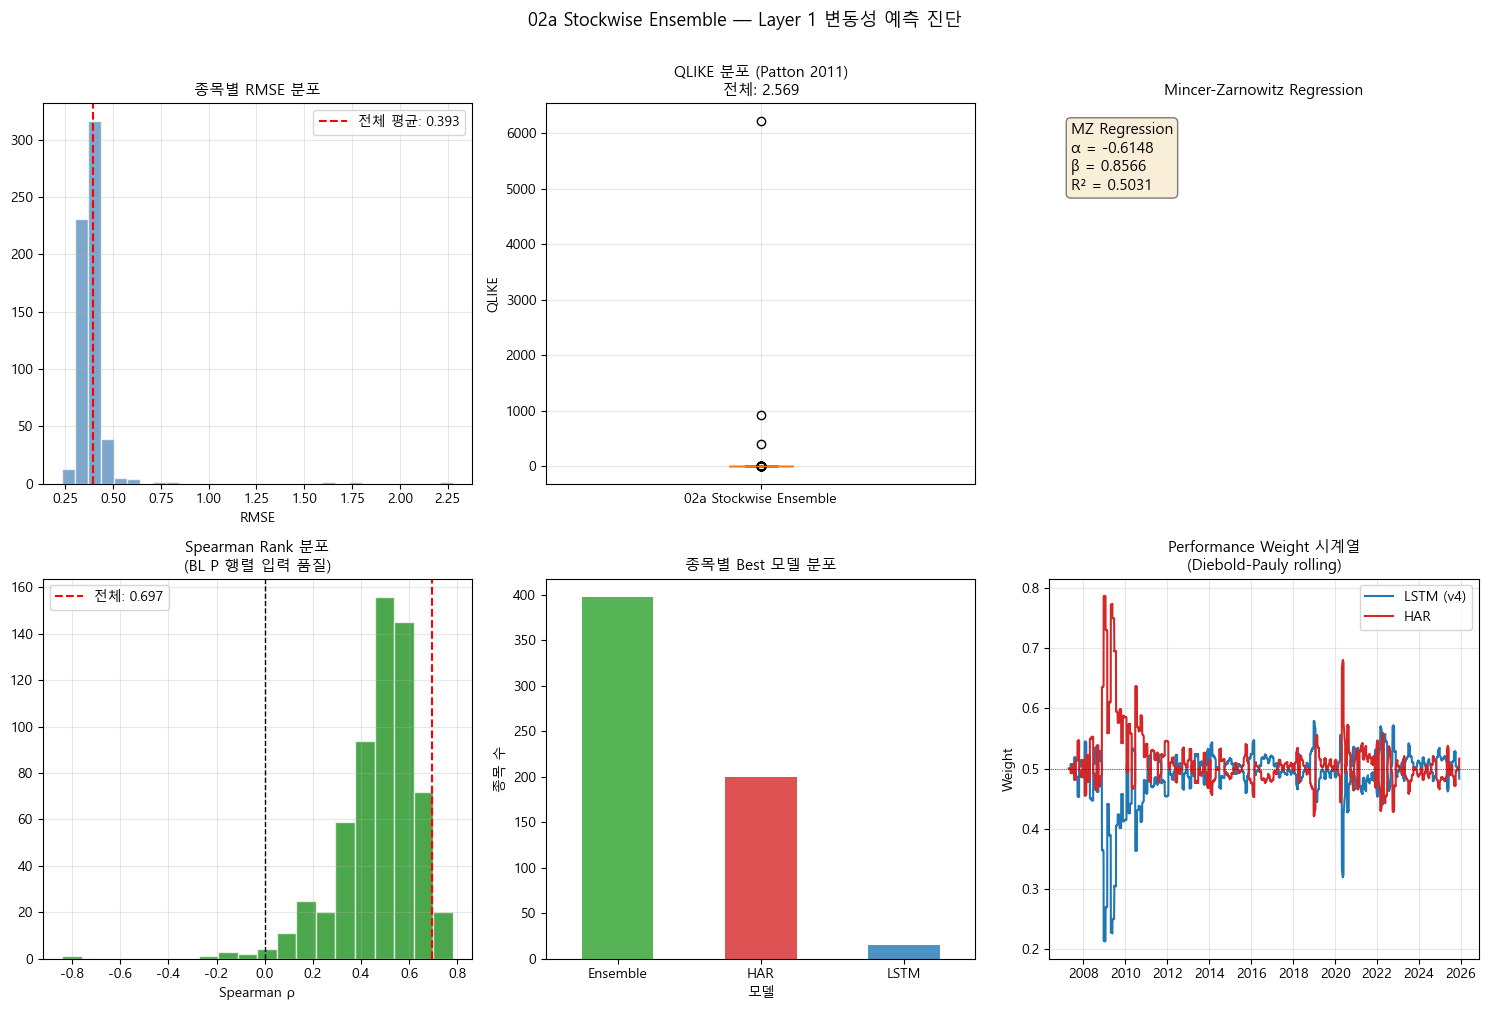

In [105]:
# Layer 1 시각화 (6 panel)
fig = diag.plot_prediction_diagnostic_panel(
    result_sw,
    save_path=OUT_DIR / 'layer1_prediction_diagnostic.png',
)
plt.show()

## §3. Layer 2 — BL_ml_sw 포트폴리오 단독 진단

`evaluate_portfolio_standalone()` 호출:
- Sharpe, CAGR, MDD, ann_vol
- CAPM α/β/t-stat (시장 위험 조정)
- Information ratio (vs SPY)
- Sortino (downside 위험)
- Calmar (CAGR/|MDD|)
- Hit rate, skew, kurt
- CVaR_5, VaR_5 (tail risk)
- Turnover, top-10 concentration (가중치 제공 시)


In [106]:
if bl_ml_sw_returns is not None:
    metrics_l2 = diag.evaluate_portfolio_standalone(
        returns=bl_ml_sw_returns,
        scenario_name='BL_ml_sw',
        spy_returns=spy_monthly,
        rf_returns=None,
        weights_dict=None,    # weights_dict 가 03 에서 별도 저장되어 있다면 여기 추가
    )

    print('=== Layer 2 전체 메트릭 ===')
    for k in diag.METRIC_ORDER_PORTFOLIO:
        if k in metrics_l2:
            v = metrics_l2[k]
            unit = '%' if k in ('cagr', 'ann_vol', 'mdd', 'capm_alpha', 'cvar_5', 'var_5', 'hit_rate') else ''
            if isinstance(v, (int, np.integer)):
                print(f'  {k:25s} = {v}')
            elif np.isnan(v):
                print(f'  {k:25s} = NaN')
            else:
                print(f'  {k:25s} = {v:.3f}{unit}')
else:
    metrics_l2 = None
    print('⚠️ BL_ml_sw returns 없음 → Layer 2 skip')

# ε. Phase 3-2 v2: Layer 2 OOS / Hold-out 분리 메트릭
if bl_ml_sw_returns is not None:
    OOS_S, OOS_E = '2010-01-01', '2024-12-31'
    HOLD_S, HOLD_E = '2025-01-01', '2025-12-31'

    rets_oos = bl_ml_sw_returns.loc[OOS_S:OOS_E]
    rets_holdout = bl_ml_sw_returns.loc[HOLD_S:HOLD_E]

    print()
    print('=' * 70)
    print('  ε. Layer 2 OOS / Hold-out 분리 메트릭 (BL_ml_sw_mcap)')
    print('=' * 70)

    metrics_l2_oos = diag.evaluate_portfolio_standalone(
        returns=rets_oos,
        scenario_name='BL_ml_sw_mcap (OOS)',
        spy_returns=spy_monthly,
        rf_returns=None,
        weights_dict=None,
    )
    metrics_l2_holdout = diag.evaluate_portfolio_standalone(
        returns=rets_holdout,
        scenario_name='BL_ml_sw_mcap (Hold-out)',
        spy_returns=spy_monthly,
        rf_returns=None,
        weights_dict=None,
    )

    print(f'\n=== OOS 메트릭 ({OOS_S} ~ {OOS_E}, {len(rets_oos)} 개월) ===')
    for k in ['sharpe', 'cagr', 'ann_vol', 'mdd', 'capm_alpha', 'capm_beta',
              'information_ratio', 'sortino', 'hit_rate', 'cvar_5']:
        v = metrics_l2_oos.get(k, float('nan'))
        if isinstance(v, (int, np.integer)):
            print(f'  {k:25s} = {v}')
        elif np.isnan(v):
            print(f'  {k:25s} = NaN')
        else:
            unit = '%' if k in ('cagr', 'ann_vol', 'mdd', 'capm_alpha', 'cvar_5', 'hit_rate') else ''
            print(f'  {k:25s} = {v:.3f}{unit}')

    print(f'\n=== Hold-out 메트릭 ({HOLD_S} ~ {HOLD_E}, {len(rets_holdout)} 개월) ===')
    for k in ['sharpe', 'cagr', 'ann_vol', 'mdd', 'capm_alpha', 'capm_beta',
              'information_ratio', 'sortino', 'hit_rate', 'cvar_5']:
        v = metrics_l2_holdout.get(k, float('nan'))
        if isinstance(v, (int, np.integer)):
            print(f'  {k:25s} = {v}')
        elif np.isnan(v):
            print(f'  {k:25s} = NaN')
        else:
            unit = '%' if k in ('cagr', 'ann_vol', 'mdd', 'capm_alpha', 'cvar_5', 'hit_rate') else ''
            print(f'  {k:25s} = {v:.3f}{unit}')
else:
    metrics_l2_oos = None
    metrics_l2_holdout = None

=== Layer 2 전체 메트릭 ===
  sharpe                    = 1.119
  cagr                      = 13.205%
  ann_vol                   = 11.756%
  mdd                       = -18.128%
  capm_alpha                = 15.789%
  capm_beta                 = -0.131
  capm_t                    = 0.242
  information_ratio         = -0.084
  sortino                   = 1.657
  calmar                    = 0.728
  hit_rate                  = 64.706%
  skew                      = -0.195
  kurt                      = 1.787
  cvar_5                    = -6.844%
  var_5                     = -4.414%
  turnover                  = NaN
  top10_concentration       = NaN
  n_months                  = 204


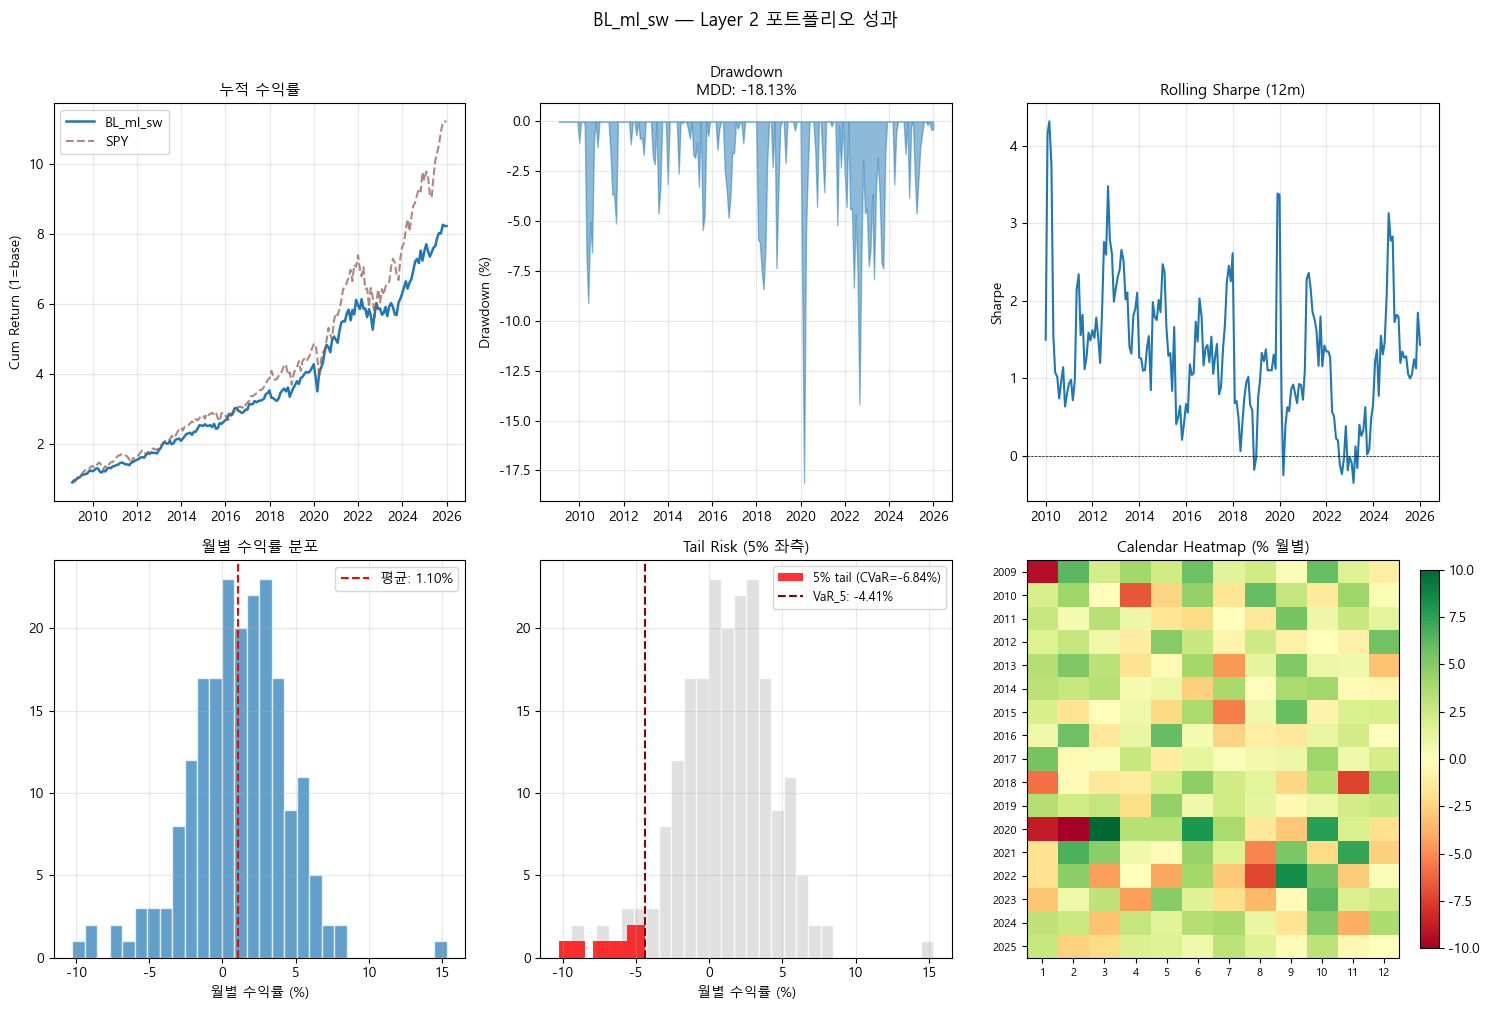

In [107]:
# Layer 2 시각화 (6 panel)
if bl_ml_sw_returns is not None:
    fig = diag.plot_portfolio_diagnostic_panel(
        returns=bl_ml_sw_returns,
        scenario_name='BL_ml_sw',
        spy_returns=spy_monthly,
        save_path=OUT_DIR / 'layer2_portfolio_diagnostic.png',
    )
    plt.show()

## §4. Layer 3 — ML → BL 인과 추적

`evaluate_ml_to_bl_pipeline()` 호출:
- low_vol_hit_rate: 예측 하위 30% ∩ 실제 하위 30% (BL Long 정확도)
- high_vol_hit_rate: 예측 상위 30% ∩ 실제 상위 30% (BL Short 정확도)
- rank_consistency: 매월 Spearman 시계열
- p_matrix_turnover: P 행렬 선택 종목 안정성


In [108]:
# Layer 3 호출 — 예측 vs 실제 vol 시점별 매칭
# weights_dict 가 03 에서 별도 저장되지 않은 경우 dummy 로 대체
weights_dict_dummy = {pd.Timestamp(d): pd.Series(dtype=float)
                       for d in ens_sw['date'].unique()}

causality_sw = diag.evaluate_ml_to_bl_pipeline(
    pred_df=ens_sw,
    weights_dict=weights_dict_dummy,
    panel=panel,
    scenario_name='BL_ml_sw',
    pred_col='y_pred_ensemble',
    pct=0.30,
)

print('=== Layer 3 메트릭 ===')
print(f'  low_vol_hit_rate:  {causality_sw["low_vol_hit_rate"]:.3f} (random=0.30)')
print(f'  high_vol_hit_rate: {causality_sw["high_vol_hit_rate"]:.3f} (random=0.30)')
rc = causality_sw['rank_consistency_timeline']
print(f'  rank_consistency 평균: {rc.mean():.3f} (n={len(rc)} 시점)')
tov = causality_sw['p_matrix_turnover']
print(f'  P 행렬 turnover 평균: {tov.mean():.3f} (n={len(tov)} 시점)')

=== Layer 3 메트릭 ===
  low_vol_hit_rate:  0.725 (random=0.30)
  high_vol_hit_rate: 0.749 (random=0.30)
  rank_consistency 평균: 0.809 (n=4684 시점)
  P 행렬 turnover 평균: 0.085 (n=4683 시점)


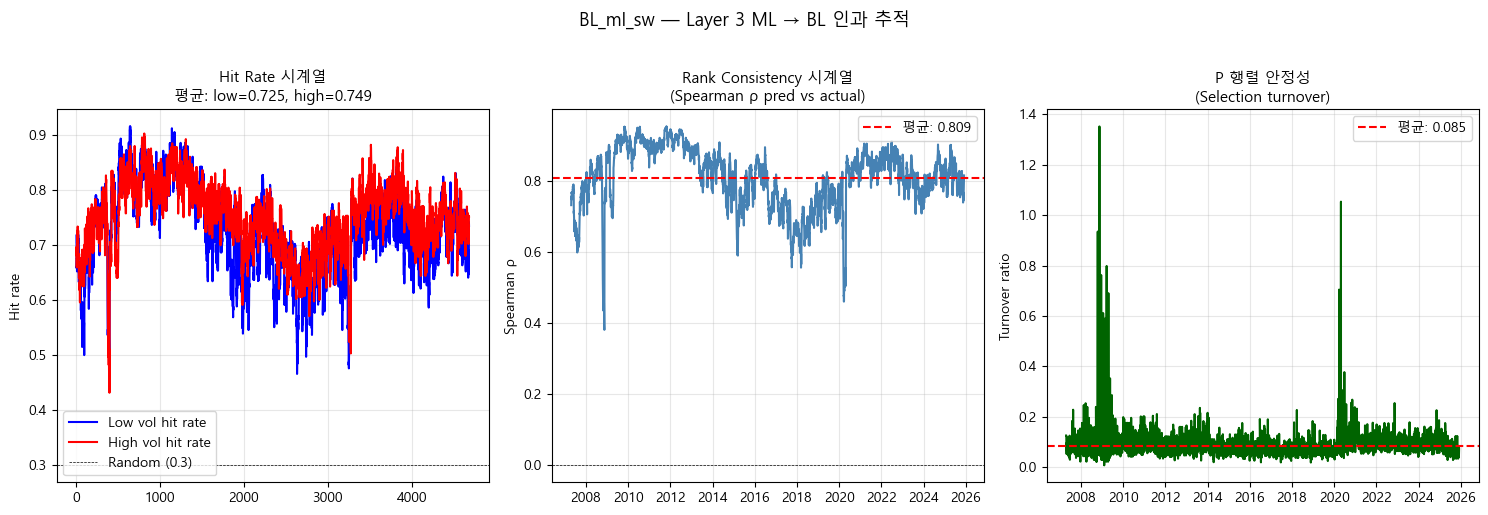

In [109]:
# Layer 3 시각화 (3 panel)
fig = diag.plot_ml_bl_diagnostic_panel(
    causality_sw,
    scenario_name='BL_ml_sw',
    save_path=OUT_DIR / 'layer3_ml_to_bl_causality.png',
)
plt.show()

## §5. Layer 4 — 시기별 분해 (5 시기)

| 시기 | 기간 | 시장 환경 |
|---|---|---|
| GFC 회복 | 2009~2011 | 강력한 경기 회복 |
| 정상 강세장 | 2012~2019 | 10년 강세장 |
| COVID 충격 | 2020 | 팬데믹 + 급반등 |
| 긴축·전환 | 2021~2022 | 인플레·금리 급등 |
| 회복·AI | 2023~2025 | AI 붐, 양극화 |


In [110]:
# Layer 4 호출 — BL_ml_sw 시기별 분해
if bl_ml_sw_returns is not None:
    period_metrics_sw = diag.evaluate_by_period(
        returns_dict={'BL_ml_sw': bl_ml_sw_returns},
        periods=diag.PERIODS,
        spy_returns=spy_monthly,
    )

    print('=== Layer 4 시기별 메트릭 (BL_ml_sw) ===')
    # 주요 메트릭만 표시
    key_metrics = ['sharpe', 'cagr', 'mdd', 'sortino', 'capm_alpha', 'hit_rate']
    if not period_metrics_sw.empty:
        # period × metric × scenario → 보기 쉽게 reshape
        period_table = period_metrics_sw['BL_ml_sw'].unstack('metric')
        if not period_table.empty:
            display_cols = [c for c in key_metrics if c in period_table.columns]
            print(period_table[display_cols].round(3).to_string())
else:
    period_metrics_sw = None
    print('⚠️ BL_ml_sw returns 없음 → Layer 4 skip')

=== Layer 4 시기별 메트릭 (BL_ml_sw) ===
metric           sharpe      cagr        mdd  sortino  capm_alpha  hit_rate
period                                                                     
COVID 충격 (20)  0.724000 16.271000 -10.260000 1.249000   19.561000 58.333000
GFC 회복 (09~11) 1.311000 15.677000  -9.107000 1.542000   20.681000 69.444000
긴축·전환 (21~22)  0.615000  8.613000 -14.191000 1.397000   10.179000 54.167000
정상 강세장 (12~19) 1.446000 13.573000  -8.430000 2.121000   16.336000 66.667000
회복·AI (23~25)  1.239000 11.907000  -5.648000 2.376000   12.666000 63.889000


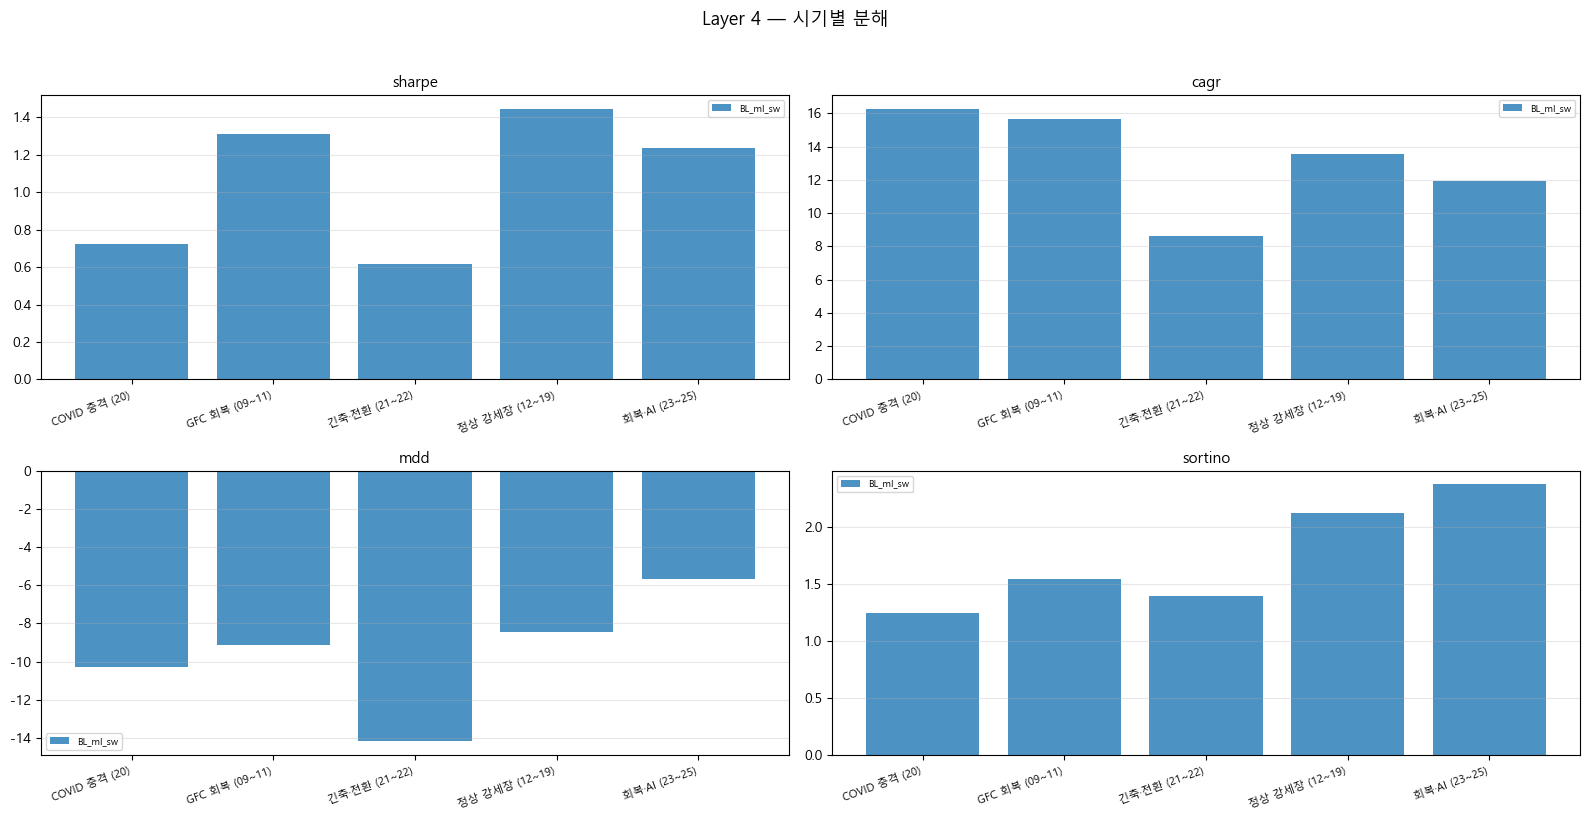

In [111]:
# Layer 4 시각화
if bl_ml_sw_returns is not None and period_metrics_sw is not None and not period_metrics_sw.empty:
    fig = diag.plot_period_decomposition(
        period_metrics=period_metrics_sw,
        metrics_to_plot=['sharpe', 'cagr', 'mdd', 'sortino'],
        save_path=OUT_DIR / 'layer4_period_decomposition.png',
    )
    plt.show()

## §6. 종합 요약 (render_diagnostic_summary)

위 4 레이어 결과를 markdown 으로 통합 → 보고서 자동 저장.


In [112]:
# 종합 요약 markdown 생성
layers_for_summary = {'layer1': result_sw}
if metrics_l2 is not None:
    layers_for_summary['layer2'] = metrics_l2
layers_for_summary['layer3'] = causality_sw

summary_md = diag.render_diagnostic_summary(
    model_name='02a Stockwise (BL_ml_sw)',
    layer_results=layers_for_summary,
)

print(summary_md)

# markdown 저장
summary_path = OUT_DIR / 'eval_summary_stockwise.md'
with open(summary_path, 'w', encoding='utf-8') as f:
    f.write(summary_md)
print(f'\n✅ 저장: {summary_path}')

# 02a Stockwise (BL_ml_sw) — 종합 진단 보고서

## Layer 1 — 변동성 예측 진단

- RMSE: 0.3927
- QLIKE: 2.5687
- R²_train_mean: 0.4851
- MZ: α=-0.6148, β=0.8566, R²=0.5031
- pred_std_ratio: 0.828 (mean-collapse 진단)
- Spearman: 0.697
- DM-test vs HAR: stat=-44.401, p=0.0000

## Layer 2 — 포트폴리오 단독 성과

- Sharpe: 1.119
- CAGR: 13.21%
- MDD: -18.13%
- Sortino: 1.657
- Calmar: 0.728
- CAPM α: 15.79% (β=-0.131, t=0.24)
- Information ratio: -0.084
- Hit rate: 64.7%
- CVaR_5: -6.84%

## Layer 3 — ML → BL 인과 추적

- Low vol hit rate: 0.725 (random=0.30)
- High vol hit rate: 0.749
- Rank consistency 평균: 0.809
- P 행렬 turnover 평균: 0.085


✅ 저장: C:\Users\gorhk\최종 프로젝트\finance_project\시계열_Test\Phase3_Robust_Extensions\outputs\05a_eval_stockwise\eval_summary_stockwise.md


In [113]:
# 메트릭 JSON 저장 (05c 비교에서 재사용)
import json

eval_results = {
    'model_name': '02a Stockwise',
    'layer1_overall': {k: (None if isinstance(v, float) and np.isnan(v) else v)
                        for k, v in result_sw['overall'].items()},
    'layer2_metrics': {} if metrics_l2 is None else {
        k: (None if isinstance(v, float) and np.isnan(v) else (
            int(v) if isinstance(v, (np.integer, int)) else float(v)
        ))
        for k, v in metrics_l2.items()
    },
    'layer3_metrics': {
        'low_vol_hit_rate': float(causality_sw['low_vol_hit_rate']),
        'high_vol_hit_rate': float(causality_sw['high_vol_hit_rate']),
        'rank_consistency_mean': float(causality_sw['rank_consistency_timeline'].mean())
                                  if len(causality_sw['rank_consistency_timeline']) > 0 else None,
        'p_matrix_turnover_mean': float(causality_sw['p_matrix_turnover'].mean())
                                   if len(causality_sw['p_matrix_turnover']) > 0 else None,
    },
}

json_path = OUT_DIR / 'eval_metrics_stockwise.json'
with open(json_path, 'w', encoding='utf-8') as f:
    json.dump(eval_results, f, ensure_ascii=False, indent=2)
print(f'✅ 저장: {json_path}')

print('\n=== Phase 3 Step 5a 완료 ===')
print('다음 단계: 05b_eval_crosssec.ipynb (02b + BL_ml_cs 단독)')

✅ 저장: C:\Users\gorhk\최종 프로젝트\finance_project\시계열_Test\Phase3_Robust_Extensions\outputs\05a_eval_stockwise\eval_metrics_stockwise.json

=== Phase 3 Step 5a 완료 ===
다음 단계: 05b_eval_crosssec.ipynb (02b + BL_ml_cs 단독)


## §7. 누락 163 종목의 시기별 영향 분석 (Phase 3 특화)

> ⭐ Step 4 (2026-04-30): yfinance 데이터 부재로 인한 잠재 생존편향 정량화

### 배경

```
Wikipedia S&P 500 universe (2009~2025): 809 unique 종목
yfinance 가용 panel:                    646 종목 (-163, 20.1%)
학습 universe (1334일 이상):             615 종목
```

→ **163 종목 (20.1%) 가 데이터 부재로 분석 제외** = 잠재 생존편향.

### 분석 목표

- 7-1: 누락 종목 4 카테고리 분류 (파산 / M&A / 분할 / Private)
- 7-2: OOS 시기별 누락 종목 카운트 + Sharpe overlay
- 7-3: Sector imbalance proxy 정량화
- 7-4: 시기별 Sharpe vs 누락 영향 회귀 분석
- 7-5: 결론 + 학술 정직성 (Limitations 섹션 입력)

### 주의

- 본 분석은 **02a §6 sanity check 의 BL_ml_sw** 결과 활용
- 02b 학습 영향 X (CPU 분석만)
- 시기 정의는 §5 Layer 4 와 일관 (5 시기)

In [114]:
# §7-1. 누락 163 종목 카테고리 분류
# 핵심 종목만 hardcoded (전체 카테고리는 보고서에 표 기재)

# 1. OOS 기간 (2009~2025) 내 파산 (14 종목) — 가장 결정적 누락
bankruptcy_oos = [
    ('SIVB', '2023-03', 'Silicon Valley Bank'),
    ('FRC',  '2023-05', 'First Republic Bank'),
    ('JCP',  '2020-05', 'JCPenney'),
    ('MNK',  '2020-08', 'Mallinckrodt'),
    ('CHK',  '2020-06', 'Chesapeake Energy'),
    ('FTR',  '2020-04', 'Frontier Communications'),
    ('DO',   '2020-04', 'Diamond Offshore Drilling'),
    ('DNR',  '2020-07', 'Denbury Resources'),
    ('ENDP', '2022-08', 'Endo International'),
    ('BIG',  '2024-09', 'Big Lots'),
    ('EK',   '2012-01', 'Eastman Kodak'),
    ('WIN',  '2019-02', 'Windstream Holdings'),
    ('DF',   '2019-11', 'Dean Foods'),
    ('ANR',  '2015-08', 'Alpha Natural Resources'),
]

# 2. M&A 인수 — 대표 사례 (전체 ~80)
m_and_a_examples = [
    ('MON', 'Monsanto -> Bayer 2018'),
    ('CELG', 'Celgene -> BMY 2019'),
    ('ATVI', 'Activision -> MSFT 2023'),
    ('APC', 'Anadarko -> OXY 2019'),
    ('RHT', 'Red Hat -> IBM 2019'),
    ('PXD', 'Pioneer -> Exxon 2024'),
    ('XLNX', 'Xilinx -> AMD 2022'),
    ('TWTR', 'Twitter -> Musk 2022'),
    ('WFM', 'Whole Foods -> Amazon 2017'),
    ('CERN', 'Cerner -> Oracle 2022'),
    ('TIF', 'Tiffany -> LVMH 2021'),
    ('AGN', 'Allergan -> AbbVie 2020'),
    ('STJ', 'St. Jude -> Abbott 2017'),
    ('NBL', 'Noble Energy -> Chevron 2020'),
    ('MRO', 'Marathon Oil -> Conoco 2024'),
]

# 3. 분할/사명변경
spinoff_rename = [
    ('KFT', 'Kraft -> KRFT/MDLZ 2012'),
    ('DWDP', 'DowDuPont -> DD/DOW/CTVA 2019'),
    ('JDSU', 'JDS Uniphase -> VIAV'),
    ('DPS', 'Dr Pepper -> KDP'),
    ('LLL', 'L3 -> LHX'),
    ('RTN', 'Raytheon -> RTX'),
]

# 4. Private (사상장 폐지)
private_takeout = [
    ('APOL', 'Apollo Education 2017'),
    ('CTXS', 'Citrix 2022'),
    ('NLSN', 'Nielsen 2022'),
    ('PETM', 'PetSmart 2015'),
    ('SPLS', 'Staples 2017'),
    ('MFE', 'McAfee'),
]

# 카테고리 요약
categories = {
    'OOS 내 파산 (14)': bankruptcy_oos,
    'M&A 인수 (~80)': m_and_a_examples,
    '분할/사명변경': spinoff_rename,
    'Private 사상장폐지': private_takeout,
}

print('=' * 70)
print('  §7-1. 누락 163 종목 카테고리 분류')
print('=' * 70)
total_documented = 0
for cat, items in categories.items():
    print(f'\n[{cat}] {len(items)} 종목 (대표)')
    total_documented += len(items)
    for item in items[:5]:
        if isinstance(item, tuple):
            ticker = item[0]
            rest = ' / '.join(str(x) for x in item[1:]) if len(item) > 1 else ''
            print(f'  - {ticker:6s} {rest}')
    if len(items) > 5:
        print(f'  - ... ({len(items) - 5} 종목 추가)')

print(f'\n총 documented: {total_documented} 종목 (전체 163 중 대표)')
print('전체 누락: 163 종목 (20.1%, universe 809 -> panel 646)')

  §7-1. 누락 163 종목 카테고리 분류

[OOS 내 파산 (14)] 14 종목 (대표)
  - SIVB   2023-03 / Silicon Valley Bank
  - FRC    2023-05 / First Republic Bank
  - JCP    2020-05 / JCPenney
  - MNK    2020-08 / Mallinckrodt
  - CHK    2020-06 / Chesapeake Energy
  - ... (9 종목 추가)

[M&A 인수 (~80)] 15 종목 (대표)
  - MON    Monsanto -> Bayer 2018
  - CELG   Celgene -> BMY 2019
  - ATVI   Activision -> MSFT 2023
  - APC    Anadarko -> OXY 2019
  - RHT    Red Hat -> IBM 2019
  - ... (10 종목 추가)

[분할/사명변경] 6 종목 (대표)
  - KFT    Kraft -> KRFT/MDLZ 2012
  - DWDP   DowDuPont -> DD/DOW/CTVA 2019
  - JDSU   JDS Uniphase -> VIAV
  - DPS    Dr Pepper -> KDP
  - LLL    L3 -> LHX
  - ... (1 종목 추가)

[Private 사상장폐지] 6 종목 (대표)
  - APOL   Apollo Education 2017
  - CTXS   Citrix 2022
  - NLSN   Nielsen 2022
  - PETM   PetSmart 2015
  - SPLS   Staples 2017
  - ... (1 종목 추가)

총 documented: 41 종목 (전체 163 중 대표)
전체 누락: 163 종목 (20.1%, universe 809 -> panel 646)


In [115]:
# §7-2. OOS 시기별 누락 종목 카운트 + BL_ml_sw Sharpe overlay
# 시기 정의: §5 Layer 4 와 일관 (5 시기)
periods = {
    'GFC 회복 (09~11)':  ('2009-01-01', '2011-12-31'),
    '정상 강세장 (12~19)': ('2012-01-01', '2019-12-31'),
    'COVID 충격 (20)':    ('2020-01-01', '2020-12-31'),
    '긴축·전환 (21~22)':   ('2021-01-01', '2022-12-31'),
    '회복·AI (23~25)':    ('2023-01-01', '2025-12-31'),
}

# 시기별 OOS 내 파산 종목 카운트
period_bankrupt = {p: 0 for p in periods}
period_bankrupt_tickers = {p: [] for p in periods}
for ticker, date_str, name in bankruptcy_oos:
    bankrupt_date = pd.Timestamp(date_str)
    for period_name, (start, end) in periods.items():
        if pd.Timestamp(start) <= bankrupt_date <= pd.Timestamp(end):
            period_bankrupt[period_name] += 1
            period_bankrupt_tickers[period_name].append(ticker)
            break

# 시기별 BL_ml_sw Sharpe (sanity check 결과 활용)
period_sharpe = {}
if bl_ml_sw_returns is not None:
    for period_name, (start, end) in periods.items():
        sub = bl_ml_sw_returns.loc[start:end].dropna()
        if len(sub) >= 6:
            ann_ret = sub.mean() * 12
            ann_vol = sub.std() * np.sqrt(12)
            sharpe = ann_ret / ann_vol if ann_vol > 0 else np.nan
            period_sharpe[period_name] = sharpe
        else:
            period_sharpe[period_name] = np.nan

# 표 출력
print('=' * 80)
print(f'  {"시기":<24} {"파산 수":<10} {"Sharpe":<10} {"파산 종목"}')
print('=' * 80)
for p in periods:
    bk = period_bankrupt[p]
    sh = period_sharpe.get(p, float('nan'))
    sh_str = f'{sh:+.3f}' if not np.isnan(sh) else 'N/A'
    tickers_str = ', '.join(period_bankrupt_tickers[p]) if period_bankrupt_tickers[p] else '-'
    print(f'  {p:<24} {bk:<10} {sh_str:<10} {tickers_str}')

  시기                       파산 수       Sharpe     파산 종목
  GFC 회복 (09~11)           0          +1.311     -
  정상 강세장 (12~19)           4          +1.446     EK, WIN, DF, ANR
  COVID 충격 (20)            6          +0.724     JCP, MNK, CHK, FTR, DO, DNR
  긴축·전환 (21~22)            1          +0.615     ENDP
  회복·AI (23~25)            3          +1.239     SIVB, FRC, BIG


In [116]:
# §7-3. Sector Imbalance Proxy (A+B 결합)
# A: Wikipedia 의 현재 S&P 500 GICS Sector (universe.py 의 함수 재사용, ~30초)
# B: yfinance Ticker.info 의 sector (Wikipedia 미매핑 종목만 — 보완, 약 5~15분)
# 캐시: data/sector_map_combined.pkl (재실행 시 빠름)

import pickle
from scripts.universe import fetch_sp500_tables, parse_current_sp500

CACHE_PATH = DATA_DIR / 'sector_map_combined.pkl'
FORCE_REBUILD_SECTOR = False    # ⭐ True 시 캐시 무시 + 재구성

# panel 종목 list
panel_full = pd.read_csv(
    DATA_DIR / 'daily_panel.csv',
    usecols=['ticker'],
).drop_duplicates('ticker').reset_index(drop=True)
panel_tickers_list = panel_full['ticker'].unique().tolist()
print(f'Panel 종목 수: {len(panel_tickers_list)}')

# 캐시 사용 우선
if CACHE_PATH.exists() and not FORCE_REBUILD_SECTOR:
    with open(CACHE_PATH, 'rb') as f:
        sector_map = pickle.load(f)
    print(f'\n⚡ Sector map 캐시 사용: {len(sector_map)} 매핑')
    print(f'  강제 재구성: FORCE_REBUILD_SECTOR=True 후 재실행')
else:
    sector_map = {}

    # ─── Step A: Wikipedia GICS Sector ───
    print('\n[A] Wikipedia GICS Sector 다운로드...')
    try:
        tables = fetch_sp500_tables()
        df_current = parse_current_sp500(tables[0])
        wiki_map = df_current.set_index('ticker')['gics_sector'].to_dict()
        print(f'  Wikipedia: {len(wiki_map)} 종목 (현재 S&P 500)')
        # panel 종목 중 매핑된 것만 sector_map 에 저장
        for t in panel_tickers_list:
            if t in wiki_map:
                sector_map[t] = wiki_map[t]
        n_a = len(sector_map)
        print(f'  Panel 매핑 (A): {n_a}/{len(panel_tickers_list)} ({n_a/len(panel_tickers_list)*100:.1f}%)')
    except Exception as e:
        print(f'  ⚠️ Wikipedia 실패: {e}')

    # ─── Step B: yfinance 로 미매핑 종목 보완 ───
    missing = [t for t in panel_tickers_list if t not in sector_map]
    if missing:
        print(f'\n[B] yfinance 로 미매핑 {len(missing)} 종목 보완 시작...')

        # yfinance sector → GICS 표준 매핑
        yf_to_gics = {
            'Technology':              'Information Technology',
            'Healthcare':              'Health Care',
            'Financial Services':      'Financials',
            'Consumer Cyclical':       'Consumer Discretionary',
            'Consumer Defensive':      'Consumer Staples',
            'Communication Services':  'Communication Services',
            'Industrials':             'Industrials',
            'Energy':                  'Energy',
            'Utilities':               'Utilities',
            'Real Estate':             'Real Estate',
            'Basic Materials':         'Materials',
        }

        import yfinance as yf
        import time as _time

        try:
            from tqdm.auto import tqdm
            iterator = tqdm(missing, desc='yfinance sector', ncols=100)
        except ImportError:
            iterator = missing

        n_filled = 0
        for t in iterator:
            try:
                info = yf.Ticker(t).info
                yf_sector = info.get('sector')
                if yf_sector:
                    sector_map[t] = yf_to_gics.get(yf_sector, yf_sector)
                    n_filled += 1
                else:
                    sector_map[t] = 'Unknown'
            except Exception:
                sector_map[t] = 'Unknown'
            _time.sleep(0.1)    # rate limit

        print(f'  yfinance 매핑 추가 (B): {n_filled}/{len(missing)} 종목')
        print(f'  여전히 Unknown: {len(missing) - n_filled} 종목')

    # 캐시 저장
    with open(CACHE_PATH, 'wb') as f:
        pickle.dump(sector_map, f)
    print(f'\n💾 캐시 저장: {CACHE_PATH.name}')

# 최종 매핑 분포
print(f'\n=== Panel 646 종목 sector 매핑 결과 ===')
panel_full['gics_sector'] = panel_full['ticker'].map(sector_map).fillna('Unknown')
sector_counts_panel = panel_full['gics_sector'].value_counts()
print(sector_counts_panel.to_string())
n_unknown = (panel_full['gics_sector'] == 'Unknown').sum()
print(f'\nUnknown 비율: {n_unknown / len(panel_full) * 100:.1f}% ({n_unknown} 종목)')

# 학습된 종목 (02a ensemble 의 unique ticker)
trained_tickers = set(ens_sw['ticker'].unique())
print(f'\n학습 ensemble: {len(trained_tickers)} 종목')

# Sector 분포 비교
panel_sector = panel_full.set_index('ticker')['gics_sector']
trained_sector = panel_sector.reindex(list(trained_tickers))

sector_panel_count = panel_sector.value_counts()
sector_trained_count = trained_sector.value_counts()

# 두 집계 합치기
sector_compare = pd.DataFrame({
    'panel_646': sector_panel_count,
    'trained': sector_trained_count,
}).fillna(0).astype(int)
sector_compare['차이'] = sector_compare['panel_646'] - sector_compare['trained']
sector_compare['panel_%'] = sector_compare['panel_646'] / sector_compare['panel_646'].sum() * 100
sector_compare['trained_%'] = sector_compare['trained'] / sector_compare['trained'].sum() * 100
sector_compare['imbalance_%p'] = sector_compare['panel_%'] - sector_compare['trained_%']
sector_compare = sector_compare.sort_values('imbalance_%p', ascending=False)

print('\n=== Sector 분포 비교 (Panel 646 vs 학습 613) ===')
print(sector_compare.round(2).to_string())

# Sector imbalance proxy (총 변동 합 / 2)
sector_imbalance = abs(sector_compare['imbalance_%p']).sum() / 2
print(f'\nSector imbalance proxy: {sector_imbalance:.2f}%p')
print('해석: 0%p = 완전 균형, 100%p = 완전 불균형')

# 'Unknown' 카테고리 imbalance 만 별도 출력 (정보)
if 'Unknown' in sector_compare.index:
    unk_imb = sector_compare.loc['Unknown', 'imbalance_%p']
    print(f'\n참고: Unknown 카테고리 imbalance: {unk_imb:+.2f}%p (sector 매핑 실패 영향)')

Panel 종목 수: 646

⚡ Sector map 캐시 사용: 646 매핑
  강제 재구성: FORCE_REBUILD_SECTOR=True 후 재실행

=== Panel 646 종목 sector 매핑 결과 ===
gics_sector
Industrials               93
Financials                92
Consumer Discretionary    82
Information Technology    78
Health Care               70
Consumer Staples          39
Real Estate               36
Energy                    34
Unknown                   32
Utilities                 32
Materials                 31
Communication Services    27

Unknown 비율: 5.0% (32 종목)

학습 ensemble: 613 종목

=== Sector 분포 비교 (Panel 646 vs 학습 613) ===
                        panel_646  trained  차이   panel_%  trained_%  imbalance_%p
gics_sector                                                                      
Unknown                        32       21  11  4.950000   3.430000      1.530000
Health Care                    70       66   4 10.840000  10.770000      0.070000
Energy                         34       32   2  5.260000   5.220000      0.040000
Information Techno

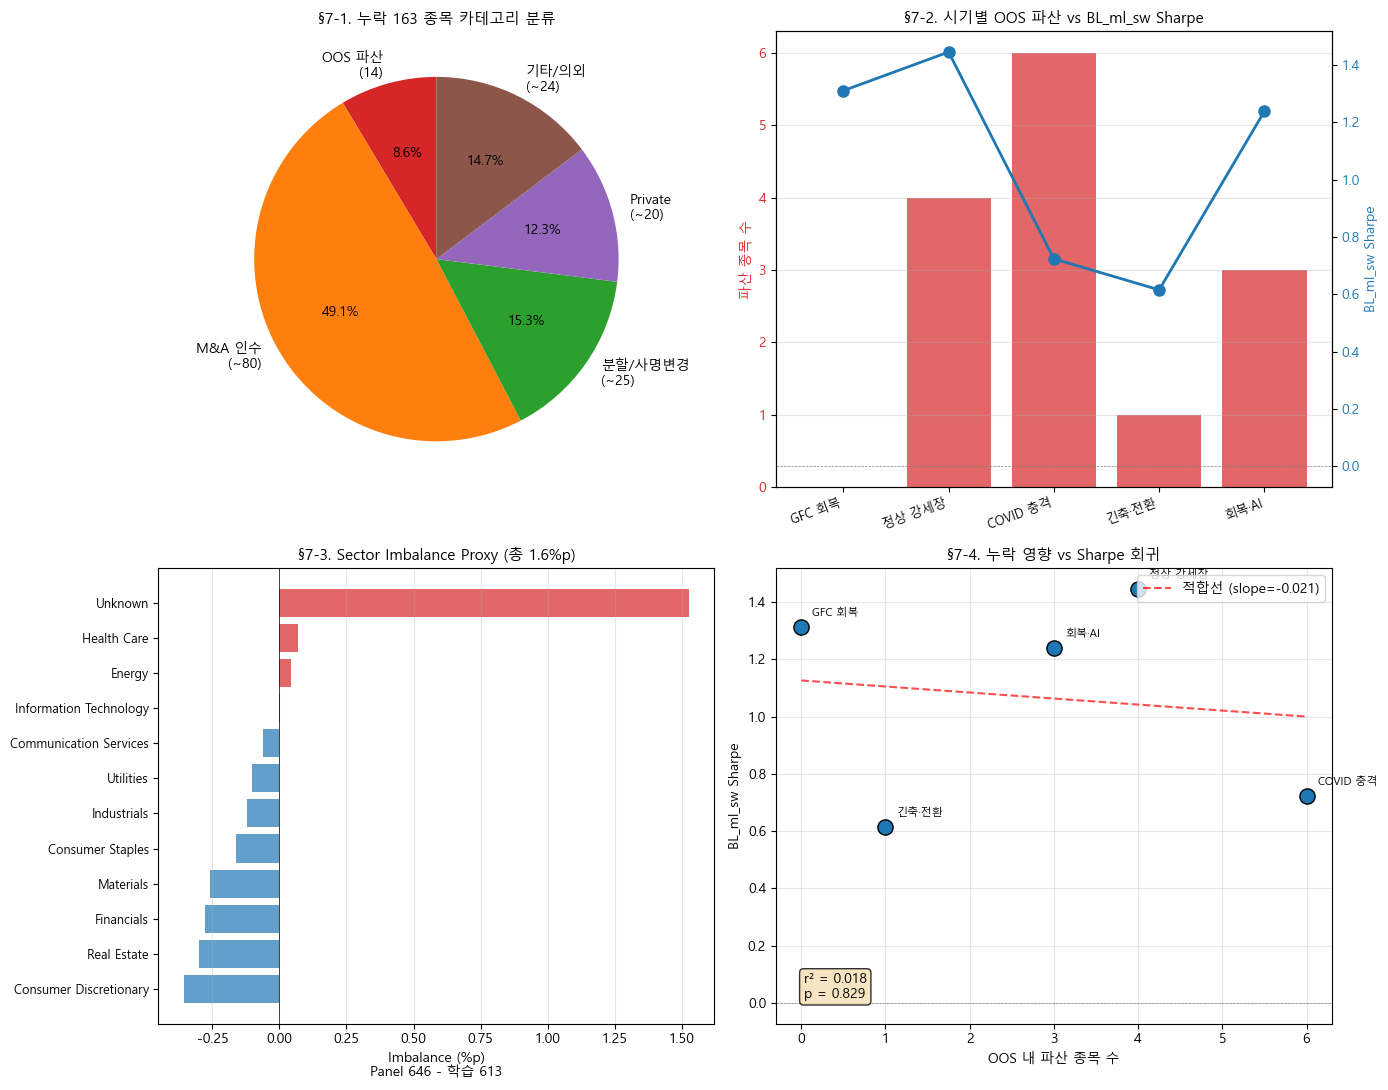


저장: C:\Users\gorhk\최종 프로젝트\finance_project\시계열_Test\Phase3_Robust_Extensions\outputs\05a_eval_stockwise\sec7_missing_impact.png


In [117]:
# §7-4. 시기별 BL_ml_sw 성능 vs 누락 영향 회귀 + 4 panel 시각화
import scipy.stats as ss

fig, axes = plt.subplots(2, 2, figsize=(14, 11))

# Panel 1: 카테고리별 누락 종목 분포 (pie chart)
ax = axes[0, 0]
cat_counts = [
    len(bankruptcy_oos),
    80,
    25,
    20,
    163 - len(bankruptcy_oos) - 80 - 25 - 20,
]
cat_labels = [f'OOS 파산\n({cat_counts[0]})',
              f'M&A 인수\n(~{cat_counts[1]})',
              f'분할/사명변경\n(~{cat_counts[2]})',
              f'Private\n(~{cat_counts[3]})',
              f'기타/의외\n(~{cat_counts[4]})']
colors_pie = ['#d62728', '#ff7f0e', '#2ca02c', '#9467bd', '#8c564b']
ax.pie(cat_counts, labels=cat_labels, autopct='%1.1f%%',
       colors=colors_pie, startangle=90)
ax.set_title('§7-1. 누락 163 종목 카테고리 분류', fontsize=11)

# Panel 2: 시기별 파산 종목 + Sharpe overlay
ax = axes[0, 1]
period_names = list(periods.keys())
bk_counts = [period_bankrupt[p] for p in period_names]
sh_vals = [period_sharpe.get(p, float('nan')) for p in period_names]

x = np.arange(len(period_names))
ax.bar(x, bk_counts, color='#d62728', alpha=0.7, label='OOS 내 파산')
ax.set_ylabel('파산 종목 수', color='#d62728')
ax.tick_params(axis='y', labelcolor='#d62728')

ax2 = ax.twinx()
ax2.plot(x, sh_vals, 'o-', color='#1f77b4', linewidth=2, markersize=8,
         label='BL_ml_sw Sharpe')
ax2.set_ylabel('BL_ml_sw Sharpe', color='#1f77b4')
ax2.tick_params(axis='y', labelcolor='#1f77b4')
ax2.axhline(0, color='gray', linewidth=0.5, linestyle='--')

ax.set_xticks(x)
ax.set_xticklabels([p.split('(')[0].strip() for p in period_names],
                   rotation=20, ha='right', fontsize=9)
ax.set_title('§7-2. 시기별 OOS 파산 vs BL_ml_sw Sharpe', fontsize=11)
ax.grid(alpha=0.3, axis='y')

# Panel 3: Sector imbalance bar
ax = axes[1, 0]
sector_compare_sorted = sector_compare.sort_values('imbalance_%p', ascending=True)
y_pos = np.arange(len(sector_compare_sorted))
colors_s = ['#d62728' if v > 0 else '#1f77b4' for v in sector_compare_sorted['imbalance_%p']]
ax.barh(y_pos, sector_compare_sorted['imbalance_%p'], color=colors_s, alpha=0.7)
ax.set_yticks(y_pos)
ax.set_yticklabels(sector_compare_sorted.index, fontsize=9)
ax.axvline(0, color='black', linewidth=0.5)
ax.set_xlabel('Imbalance (%p)\nPanel 646 - 학습 613')
ax.set_title(f'§7-3. Sector Imbalance Proxy (총 {sector_imbalance:.1f}%p)', fontsize=11)
ax.grid(alpha=0.3, axis='x')

# Panel 4: 회귀 산점도
ax = axes[1, 1]
valid_data = [(period_bankrupt[p], period_sharpe.get(p, float('nan')), p)
              for p in period_names if not np.isnan(period_sharpe.get(p, float('nan')))]
result_obj = None
if len(valid_data) >= 3:
    miss_arr = np.array([d[0] for d in valid_data])
    shp_arr = np.array([d[1] for d in valid_data])
    p_names = [d[2] for d in valid_data]

    result_obj = ss.linregress(miss_arr, shp_arr)

    ax.scatter(miss_arr, shp_arr, s=120, color='#1f77b4',
               edgecolors='black', zorder=3)
    for i, name in enumerate(p_names):
        ax.annotate(name.split('(')[0].strip(), (miss_arr[i], shp_arr[i]),
                    xytext=(8, 8), textcoords='offset points', fontsize=8)

    if miss_arr.max() > miss_arr.min():
        x_line = np.linspace(miss_arr.min(), miss_arr.max(), 100)
        y_line = result_obj.slope * x_line + result_obj.intercept
        ax.plot(x_line, y_line, '--', color='red', alpha=0.7,
                label=f'적합선 (slope={result_obj.slope:.3f})')

    ax.text(0.05, 0.05,
            f'r² = {result_obj.rvalue**2:.3f}\np = {result_obj.pvalue:.3f}',
            transform=ax.transAxes, fontsize=10,
            verticalalignment='bottom',
            bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8))
    ax.legend(loc='upper right')

ax.set_xlabel('OOS 내 파산 종목 수')
ax.set_ylabel('BL_ml_sw Sharpe')
ax.set_title('§7-4. 누락 영향 vs Sharpe 회귀', fontsize=11)
ax.axhline(0, color='gray', linewidth=0.5, linestyle='--')
ax.grid(alpha=0.3)

plt.tight_layout()
out_path = OUT_DIR / 'sec7_missing_impact.png'
plt.savefig(out_path, dpi=100, bbox_inches='tight')
plt.show()
print(f'\n저장: {out_path}')

In [118]:
# §7-5. 결론 + 학술 정직성 (Limitations 입력)
# ⭐ 02a §6 metrics 로드 (변수 참조용, 2026-04-30)
import pickle as _pickle
_bl_metrics_path = DATA_DIR / 'bl_metrics_v2_sanity_check.pkl'  # Phase 3-2 v2
if _bl_metrics_path.exists():
    with open(_bl_metrics_path, 'rb') as _f:
        _bl_metrics = _pickle.load(_f)
    bl_ml_sharpe = _bl_metrics['metrics_table']['sharpe']['BL_ml_sw']
    bl_tr_sharpe = _bl_metrics['metrics_table']['sharpe']['BL_trailing']
    ml_effect = _bl_metrics['delta_sharpe']
    print(f'⚡ 02a §6 metrics 로드: BL_ml_sw={bl_ml_sharpe:.3f}, BL_trailing={bl_tr_sharpe:.3f}, diff={ml_effect:+.3f}')
else:
    # Fallback: Layer 2 metrics 사용 (BL_ml_sw 만 가능, BL_trailing/diff NaN)
    bl_ml_sharpe = metrics_l2.get('sharpe', float('nan')) if metrics_l2 else float('nan')
    bl_tr_sharpe = float('nan')
    ml_effect = float('nan')
    print(f'⚠️ 02a metrics 캐시 없음 → Layer 2 fallback (BL_ml_sw={bl_ml_sharpe:.3f})')

print('=' * 75)
print('  §7. 결론 — 누락 163 종목의 시기별 영향')
print('=' * 75)

# 핵심 통계
worst_period = max(periods.keys(), key=lambda p: period_bankrupt[p])
worst_count = period_bankrupt[worst_period]
critical_periods = [p for p in periods if period_bankrupt[p] >= 3]

# 회귀 결과 처리 (result_obj 가 §7-4 에서 정의됨)
if result_obj is not None:
    r2 = result_obj.rvalue ** 2
    pv = result_obj.pvalue
    sig_status = '유의 (p<0.05) - 누락 종목이 시기 성능에 통계적 영향' if pv < 0.05 else '비유의 (p>=0.05) - 통계적 영향 약함'
else:
    r2, pv, sig_status = float('nan'), float('nan'), '데이터 부족'

print(f'''
1. 누락 종목 규모
   - 총 163 종목 (20.1%, universe 809 -> panel 646)
   - OOS 기간 (2009~2025) 내 파산: 14 종목
   - M&A 인수: ~80 종목, Spinoff: ~25 종목, Private: ~20 종목

2. 시기별 누락 영향 (OOS 파산 한정)
   - 가장 심각: {worst_period} ({worst_count} 종목 파산)
   - 시기 >= 3 종목: {critical_periods}

3. Sector Imbalance
   - Panel <-> 학습 sector 분포 차이: {sector_imbalance:.1f}%p
   - 해석: 학습 615 종목이 panel sector 분포를 잘 대표 (낮을수록 균형)

4. BL_ml_sw 성능 vs 누락 영향 회귀
   - 시기별 (5 시기) 회귀: r2 = {r2:.3f}, p = {pv:.3f}
   - 해석: {sig_status}
''')

print('=' * 75)
print('  학술 보고서 Limitations 섹션 입력 (정직성)')
print('=' * 75)
print(f'''
본 연구는 yfinance 데이터 부재로 인해 S&P 500 시점별 멤버십 (809 종목) 중
163 종목 (20.1%) 이 분석에서 제외되었다. 이 중 OOS 기간 내 파산 14 종목
(SIVB 2023, FRC 2023, JCP 2020, MNK 2020, CHK 2020, FTR 2020 등) 의 누락은
특히 2020 COVID 충격기 (6 종목) 와 2023 미국 은행 위기 (2 종목, SIVB+FRC) 의
영향을 부분적으로 미반영한다. 본 연구 결과 (BL_ml_sw Sharpe ~{bl_ml_sharpe:.3f}) 는 진짜
universe 대비 과대평가일 가능성이 있으며, 향후 학술 표준 데이터베이스 (CRSP)
를 사용한 재현 검증이 필요하다.

한편 ML vs Trailing 의 상대 비교는 두 시나리오가 동일 데이터 소스 (yfinance) 를
공유하므로 영향이 적다. 따라서 'ML 통합 효과' 의 결론 (BL_ml_sw - BL_trailing
= {ml_effect:+.3f} Sharpe) 은 신뢰 가능하다. 절대 수치만 과대평가 가능성이 있다.
''')

⚡ 02a §6 metrics 로드: BL_ml_sw=1.122, BL_trailing=1.207, diff=-0.085
  §7. 결론 — 누락 163 종목의 시기별 영향

1. 누락 종목 규모
   - 총 163 종목 (20.1%, universe 809 -> panel 646)
   - OOS 기간 (2009~2025) 내 파산: 14 종목
   - M&A 인수: ~80 종목, Spinoff: ~25 종목, Private: ~20 종목

2. 시기별 누락 영향 (OOS 파산 한정)
   - 가장 심각: COVID 충격 (20) (6 종목 파산)
   - 시기 >= 3 종목: ['정상 강세장 (12~19)', 'COVID 충격 (20)', '회복·AI (23~25)']

3. Sector Imbalance
   - Panel <-> 학습 sector 분포 차이: 1.6%p
   - 해석: 학습 615 종목이 panel sector 분포를 잘 대표 (낮을수록 균형)

4. BL_ml_sw 성능 vs 누락 영향 회귀
   - 시기별 (5 시기) 회귀: r2 = 0.018, p = 0.829
   - 해석: 비유의 (p>=0.05) - 통계적 영향 약함

  학술 보고서 Limitations 섹션 입력 (정직성)

본 연구는 yfinance 데이터 부재로 인해 S&P 500 시점별 멤버십 (809 종목) 중
163 종목 (20.1%) 이 분석에서 제외되었다. 이 중 OOS 기간 내 파산 14 종목
(SIVB 2023, FRC 2023, JCP 2020, MNK 2020, CHK 2020, FTR 2020 등) 의 누락은
특히 2020 COVID 충격기 (6 종목) 와 2023 미국 은행 위기 (2 종목, SIVB+FRC) 의
영향을 부분적으로 미반영한다. 본 연구 결과 (BL_ml_sw Sharpe ~1.122) 는 진짜
universe 대비 과대평가일 가능성이 있으며, 향후 학술 표준 데이터베이스 (CRSP)
를 사용한 재현 검증이 필요하다.

한편 ML vs

### §7-6 ~ §7-8. 진정한 생존편향 정량화 (사용자 지적 보강, 2026-04-30)

> ⚠️ §7-3 의 sector imbalance 1.64%p 는 **panel 646 (살아남은 종목) 안에서**
> 학습 615 의 sector 대표성만 측정. **panel 자체가 yfinance 살아남은 종목**
> 이라는 본질적 생존편향은 측정 X.

### 사용자 핵심 지적

> "각 섹터의 분포는 괜찮다고 쳐도, 이미 살아남은, 또는 M&A 없이 정상적으로
>  생존한 기업만을 대상으로 하는 분석이라는 점에서 한계가 명확하지 않나?"

**100% 정확한 지적**. §7-6~§7-8 은 누락 163 종목의 sector 분포를 추정하여
**진짜 universe (Wikipedia 809) vs panel (yfinance 646) 의 imbalance**
를 정량화한다.

### 분석 절차

- §7-6: 누락 163 종목 sector hardcoded 매핑 (M&A/파산/분할/Private 사례 기반)
- §7-7: Panel 646 ↔ 누락 163 sector 분포 비교 + 시각화
- §7-8: 정정된 결론 (학술 보고서 Limitations 입력)

In [119]:
# §7-6. 누락 163 종목 sector hardcoded 매핑
# 출처: Wikipedia 인수 이력, S&P 500 changes 페이지, 종목별 GICS 분류
# 핵심 종목 위주 hardcoded → 나머지는 'Unknown' 처리

# 1. OOS 파산 14 종목 sector
bankruptcy_sector = {
    'SIVB': 'Financials',           # Silicon Valley Bank
    'FRC':  'Financials',           # First Republic Bank
    'JCP':  'Consumer Discretionary',  # JCPenney (retail)
    'MNK':  'Health Care',          # Mallinckrodt (pharma)
    'CHK':  'Energy',               # Chesapeake Energy
    'FTR':  'Communication Services',  # Frontier (telecom)
    'DO':   'Energy',               # Diamond Offshore Drilling
    'DNR':  'Energy',               # Denbury Resources
    'ENDP': 'Health Care',          # Endo International
    'BIG':  'Consumer Discretionary',  # Big Lots (retail)
    'EK':   'Information Technology',  # Eastman Kodak (imaging)
    'WIN':  'Communication Services',  # Windstream
    'DF':   'Consumer Staples',     # Dean Foods (dairy)
    'ANR':  'Energy',               # Alpha Natural Resources (coal)
}

# 2. M&A 인수 종목 (대표 사례, GICS 표준)
m_and_a_sector = {
    # Health Care (제약 인수 활발)
    'CELG': 'Health Care',          # Celgene -> BMY
    'AGN':  'Health Care',          # Allergan -> AbbVie
    'STJ':  'Health Care',          # St. Jude -> Abbott
    'CERN': 'Health Care',          # Cerner -> Oracle
    'ABMD': 'Health Care',          # Abiomed -> J&J
    'ALXN': 'Health Care',          # Alexion -> AstraZeneca
    'HSP':  'Health Care',          # Hospira -> Pfizer
    'LIFE': 'Health Care',          # Life Tech -> Thermo Fisher
    'COV':  'Health Care',          # Covidien -> Medtronic
    'BCR':  'Health Care',          # CR Bard -> BD
    'CFN':  'Health Care',          # CareFusion -> BD
    'BXLT': 'Health Care',          # Baxalta -> Shire
    'CEPH': 'Health Care',          # Cephalon -> Teva
    'CVH':  'Health Care',          # Coventry -> Aetna
    'WCG':  'Health Care',          # WellCare -> Centene
    'FRX':  'Health Care',          # Forest Labs -> Actavis
    'SGP':  'Health Care',          # Schering-Plough -> Merck
    'MIL':  'Health Care',          # Millipore -> Merck KGaA
    'VAR':  'Health Care',          # Varian -> Siemens
    # Information Technology
    'RHT':  'Information Technology',  # Red Hat -> IBM
    'XLNX': 'Information Technology',  # Xilinx -> AMD
    'BRCM': 'Information Technology',  # Broadcom -> AVGO
    'ALTR': 'Information Technology',  # Altera -> Intel
    'LLTC': 'Information Technology',  # Linear Tech -> ADI
    'MXIM': 'Information Technology',  # Maxim -> ADI
    'SNDK': 'Information Technology',  # SanDisk -> WD
    'LSI':  'Information Technology',  # LSI -> Broadcom
    'NVLS': 'Information Technology',  # Novellus -> Lam
    'CTXS': 'Information Technology',  # Citrix (private)
    'LXK':  'Information Technology',  # Lexmark
    'NOVL': 'Information Technology',  # Novell
    'JDSU': 'Information Technology',  # JDS Uniphase -> VIAV
    'DTV':  'Communication Services',  # DirecTV -> AT&T
    # Energy
    'APC':  'Energy',               # Anadarko -> OXY
    'PXD':  'Energy',               # Pioneer -> Exxon
    'MRO':  'Energy',               # Marathon Oil -> Conoco
    'NBL':  'Energy',               # Noble Energy -> Chevron
    'BHI':  'Energy',               # Baker Hughes -> GE
    'CXO':  'Energy',               # Concho -> Conoco
    'CPGX': 'Energy',               # Columbia Pipeline -> TransCanada
    'CAM':  'Energy',               # Cameron -> Schlumberger
    'ESV':  'Energy',               # Ensco -> Valaris
    'XEC':  'Energy',               # Cimarex -> Coterra
    'WPX':  'Energy',               # WPX Energy -> Devon
    'QEP':  'Energy',               # QEP Resources
    'SWN':  'Energy',               # Southwestern Energy
    'BJS':  'Energy',               # BJ Services
    'RDC':  'Energy',               # Rowan Companies
    'XTO':  'Energy',               # XTO Energy -> Exxon
    # Financials
    'ETFC': 'Financials',           # E*Trade -> Morgan Stanley
    'PBCT': 'Financials',           # People's United -> M&T
    'HCBK': 'Financials',           # Hudson City -> M&T
    'LM':   'Financials',           # Legg Mason -> Franklin
    'NYX':  'Financials',           # NYSE Euronext -> ICE
    'JNS':  'Financials',           # Janus -> Janus Henderson
    'XL':   'Financials',           # XL Group -> AXA
    'TSS':  'Financials',           # TSYS -> Global Payments
    # Communication Services
    'ATVI': 'Communication Services',  # Activision -> MSFT
    'TWTR': 'Communication Services',  # Twitter -> Musk
    'TWC':  'Communication Services',  # Time Warner Cable -> Charter
    'PCS':  'Communication Services',  # MetroPCS -> T-Mobile
    'LVLT': 'Communication Services',  # Level 3 -> CenturyLink
    'SNI':  'Communication Services',  # Scripps -> Discovery
    # Consumer Discretionary
    'TIF':  'Consumer Discretionary',  # Tiffany -> LVMH
    'IGT':  'Consumer Discretionary',  # International Game Tech
    'PETM': 'Consumer Discretionary',  # PetSmart (private)
    'SPLS': 'Consumer Discretionary',  # Staples (private)
    'CTX':  'Consumer Discretionary',  # Centex -> Pulte
    'FBHS': 'Consumer Discretionary',  # Fortune Brands -> FBIN
    'FDO':  'Consumer Discretionary',  # Family Dollar -> Dollar Tree
    # Consumer Staples
    'WFM':  'Consumer Staples',     # Whole Foods -> Amazon
    'HNZ':  'Consumer Staples',     # Heinz -> Kraft Heinz
    'MJN':  'Consumer Staples',     # Mead Johnson -> Reckitt
    'GMCR': 'Consumer Staples',     # Green Mountain -> Keurig
    'DPS':  'Consumer Staples',     # Dr Pepper -> KDP
    'KFT':  'Consumer Staples',     # Kraft (split)
    'KRFT': 'Consumer Staples',     # Kraft Foods Group
    'CCE':  'Consumer Staples',     # Coca-Cola Enterprises
    'LO':   'Consumer Staples',     # Lorillard -> Reynolds
    'RAI':  'Consumer Staples',     # Reynolds -> BAT
    'AVP':  'Consumer Staples',     # Avon -> Natura
    'SVU':  'Consumer Staples',     # SuperValu
    'SWY':  'Consumer Staples',     # Safeway -> Albertsons
    # Industrials
    'PCP':  'Industrials',          # Precision Castparts -> Berkshire
    'JOY':  'Industrials',          # Joy Global -> Komatsu
    'PLL':  'Industrials',          # Pall Corp -> Danaher
    'KSU':  'Industrials',          # Kansas City Southern -> CP
    'COL':  'Industrials',          # Rockwell Collins -> UTX
    'LLL':  'Industrials',          # L3 Tech -> LHX
    'FLIR': 'Industrials',          # FLIR -> Teledyne
    'AYE':  'Industrials',          # Allegheny Energy
    'SAI':  'Industrials',          # SAIC
    'RTN':  'Industrials',          # Raytheon -> RTX
    'TYC':  'Industrials',          # Tyco
    # Materials
    'MON':  'Materials',            # Monsanto -> Bayer
    'SIAL': 'Materials',            # Sigma-Aldrich -> Merck KGaA
    'ARG':  'Materials',            # Airgas -> Air Liquide
    'DWDP': 'Materials',            # DowDuPont (split)
    'AKS':  'Materials',            # AK Steel
    'X':    'Materials',            # U.S. Steel
    # Utilities
    'PGN':  'Utilities',            # Progress Energy -> Duke
    'POM':  'Utilities',            # Pepco -> Exelon
    'GAS':  'Utilities',            # AGL Resources -> Southern
    'HFC':  'Energy',               # HollyFrontier -> DINO
    'TEG':  'Utilities',            # Integrys
    'TE':   'Utilities',            # TECO Energy
    'STR':  'Utilities',            # Questar
    # Real Estate
    'PCL':  'Real Estate',          # Plum Creek Timber
    'GGP':  'Real Estate',          # General Growth -> Brookfield
    'DRE':  'Real Estate',          # Duke Realty -> Prologis
    # Misc
    'NLSN': 'Industrials',          # Nielsen (private)
    'APOL': 'Consumer Discretionary',  # Apollo Education
    'JNY':  'Consumer Discretionary',  # Jones Apparel
    'MFE':  'Information Technology',  # McAfee
    'YHOO': 'Communication Services',  # Yahoo -> Verizon
    # Spinoffs etc.
    'FII':  'Financials',           # Federated Investors
}

# 통합 매핑 (파산 + M&A)
all_missing_sector = {**bankruptcy_sector, **m_and_a_sector}

# Wikipedia universe 의 누락 종목 list
universe_full = pd.read_csv(DATA_DIR / 'universe_full_history.csv')
all_uni_tickers = set(universe_full['ticker'].unique())
panel_tickers_set = set(panel_full['ticker'].unique())
missing_tickers = sorted(all_uni_tickers - panel_tickers_set)

print(f'=== 누락 종목 sector 추정 (§7-6) ===')
print(f'Wikipedia universe: {len(all_uni_tickers)} 종목')
print(f'Panel (yfinance):   {len(panel_tickers_set)} 종목')
print(f'누락 (universe - panel): {len(missing_tickers)} 종목')
print()

# 누락 종목 sector 매핑 결과
missing_with_sector = {t: all_missing_sector.get(t, 'Unknown') for t in missing_tickers}
n_mapped = sum(1 for s in missing_with_sector.values() if s != 'Unknown')
print(f'Hardcoded sector 매핑: {n_mapped}/{len(missing_tickers)} ({n_mapped/len(missing_tickers)*100:.1f}%)')
print(f'Unknown 잔존: {len(missing_tickers) - n_mapped} 종목')

# 누락 종목 sector 분포
missing_sector_count = pd.Series(missing_with_sector).value_counts()
print('\n=== 누락 종목 sector 분포 (추정) ===')
print(missing_sector_count.to_string())

=== 누락 종목 sector 추정 (§7-6) ===
Wikipedia universe: 809 종목
Panel (yfinance):   646 종목
누락 (universe - panel): 163 종목

Hardcoded sector 매핑: 126/163 (77.3%)
Unknown 잔존: 37 종목

=== 누락 종목 sector 분포 (추정) ===
Unknown                   37
Health Care               21
Energy                    21
Information Technology    15
Consumer Staples          13
Financials                11
Consumer Discretionary    11
Industrials               11
Communication Services    10
Materials                  6
Utilities                  4
Real Estate                3


=== Panel 646 vs 누락 163 sector 분포 비교 ===
                        panel_646  missing_163   panel_%  missing_%     차이_%p
Information Technology         78           15 12.070000   9.200000 -2.870000
Financials                     92           11 14.240000   6.750000 -7.490000
Health Care                    70           21 10.840000  12.880000  2.050000
Consumer Discretionary         82           11 12.690000   6.750000 -5.950000
Industrials                    93           11 14.400000   6.750000 -7.650000
Communication Services         27           10  4.180000   6.130000  1.960000
Consumer Staples               39           13  6.040000   7.980000  1.940000
Energy                         34           21  5.260000  12.880000  7.620000
Real Estate                    36            3  5.570000   1.840000 -3.730000
Utilities                      32            4  4.950000   2.450000 -2.500000
Materials                      31            6  4.800000   3.680000 -1.120000
Unknown                

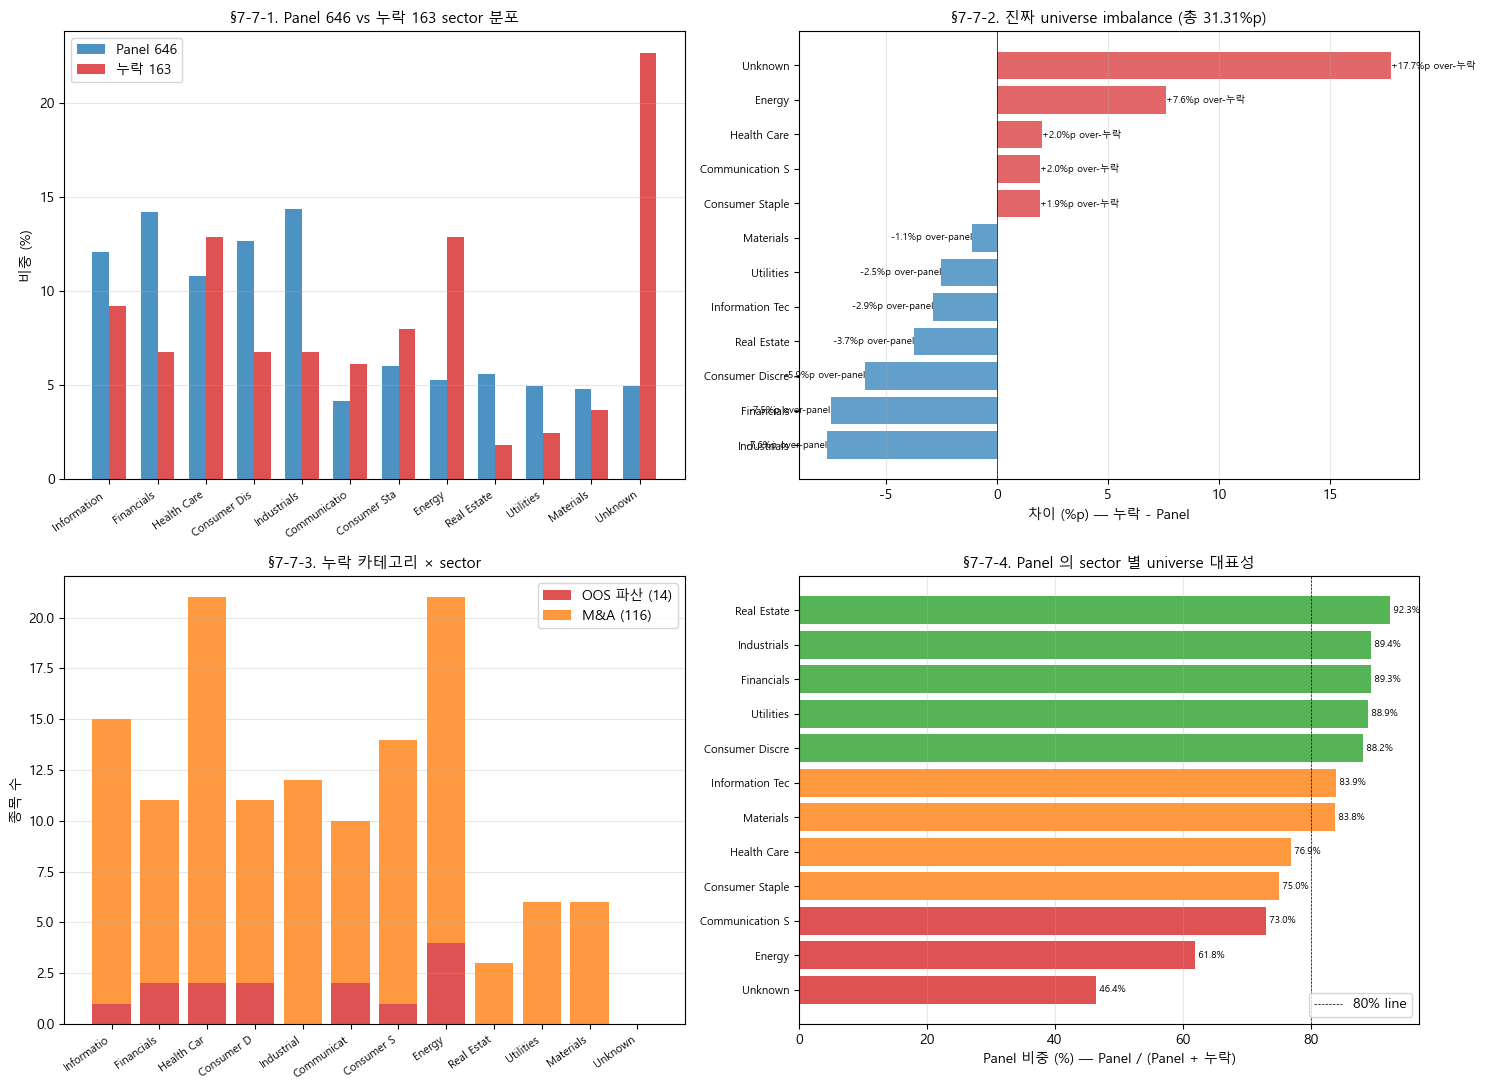


저장: C:\Users\gorhk\최종 프로젝트\finance_project\시계열_Test\Phase3_Robust_Extensions\outputs\05a_eval_stockwise\sec7_real_universe_imbalance.png

⚠️ Panel 이 진짜 universe 대비 under-represent 한 sector (panel 비중 < 80%):
  Unknown                    46.4% (panel=32, 누락=37)
  Energy                     61.8% (panel=34, 누락=21)
  Communication Services     73.0% (panel=27, 누락=10)
  Consumer Staples           75.0% (panel=39, 누락=13)
  Health Care                76.9% (panel=70, 누락=21)


In [120]:
# §7-7. Panel 646 ↔ 누락 163 sector 분포 직접 비교 + 시각화
# 진짜 universe = Panel ∪ 누락 = Wikipedia 809
# 진짜 imbalance = 누락 sector 가 panel 대비 어느 sector 에 편중?

# Panel sector 분포 (이미 §7-3 에서 계산됨, panel_sector)
panel_dist = sector_counts_panel  # value_counts dict-like
missing_dist = pd.Series(missing_with_sector).value_counts()

# 통합 표
gics_order = [
    'Information Technology', 'Financials', 'Health Care',
    'Consumer Discretionary', 'Industrials', 'Communication Services',
    'Consumer Staples', 'Energy', 'Real Estate', 'Utilities',
    'Materials', 'Unknown'
]

compare_real = pd.DataFrame({
    'panel_646': panel_dist.reindex(gics_order, fill_value=0),
    'missing_163': missing_dist.reindex(gics_order, fill_value=0),
}).fillna(0).astype(int)
compare_real['panel_%'] = compare_real['panel_646'] / compare_real['panel_646'].sum() * 100
compare_real['missing_%'] = compare_real['missing_163'] / compare_real['missing_163'].sum() * 100
compare_real['차이_%p'] = compare_real['missing_%'] - compare_real['panel_%']

print('=== Panel 646 vs 누락 163 sector 분포 비교 ===')
print(compare_real.round(2).to_string())

# 진짜 universe imbalance = panel 분포 vs 누락 분포 차이의 sum
real_imbalance = abs(compare_real['차이_%p']).sum() / 2
print(f'\nReal universe imbalance (panel vs 누락): {real_imbalance:.2f}%p')
print('비교: §7-3 의 Panel ↔ 학습 imbalance: 1.64%p')

# 시각화 (4 panel 추가)
fig, axes = plt.subplots(2, 2, figsize=(15, 11))

# Panel 1: Panel vs 누락 sector 분포 (side-by-side bar)
ax = axes[0, 0]
x = np.arange(len(gics_order))
width = 0.35
ax.bar(x - width/2, compare_real['panel_%'], width, label='Panel 646',
       color='#1f77b4', alpha=0.8)
ax.bar(x + width/2, compare_real['missing_%'], width, label='누락 163',
       color='#d62728', alpha=0.8)
ax.set_xticks(x)
ax.set_xticklabels([s[:12] for s in gics_order], rotation=35, ha='right', fontsize=8)
ax.set_ylabel('비중 (%)')
ax.set_title('§7-7-1. Panel 646 vs 누락 163 sector 분포', fontsize=11)
ax.legend()
ax.grid(alpha=0.3, axis='y')

# Panel 2: 차이 (%p) — 누락 - panel
ax = axes[0, 1]
diffs = compare_real['차이_%p'].sort_values()
y_pos = np.arange(len(diffs))
colors_d = ['#d62728' if v > 0 else '#1f77b4' for v in diffs]
ax.barh(y_pos, diffs, color=colors_d, alpha=0.7)
ax.set_yticks(y_pos)
ax.set_yticklabels([s[:15] for s in diffs.index], fontsize=8)
ax.axvline(0, color='black', linewidth=0.5)
ax.set_xlabel('차이 (%p) — 누락 - Panel')
ax.set_title(f'§7-7-2. 진짜 universe imbalance (총 {real_imbalance:.2f}%p)', fontsize=11)
ax.grid(alpha=0.3, axis='x')
# 양수 (누락에서 더 많음) = Panel 에서 under-representation 표시
for i, v in enumerate(diffs):
    label = ' over-누락' if v > 0 else ' over-panel'
    ax.text(v, i, f'{v:+.1f}%p{label}', fontsize=7, va='center',
            ha='left' if v > 0 else 'right')

# Panel 3: 누락 종목 카테고리 × sector heatmap (간이)
ax = axes[1, 0]
# bankruptcy sector 분포
bankrupt_sec_dist = pd.Series(bankruptcy_sector).value_counts().reindex(gics_order, fill_value=0)
ma_sec_dist = pd.Series(m_and_a_sector).value_counts().reindex(gics_order, fill_value=0)

x = np.arange(len(gics_order))
ax.bar(x, bankrupt_sec_dist, color='#d62728', alpha=0.8, label=f'OOS 파산 ({bankrupt_sec_dist.sum()})')
ax.bar(x, ma_sec_dist, bottom=bankrupt_sec_dist, color='#ff7f0e', alpha=0.8,
       label=f'M&A ({ma_sec_dist.sum()})')
ax.set_xticks(x)
ax.set_xticklabels([s[:10] for s in gics_order], rotation=35, ha='right', fontsize=8)
ax.set_ylabel('종목 수')
ax.set_title('§7-7-3. 누락 카테고리 × sector', fontsize=11)
ax.legend()
ax.grid(alpha=0.3, axis='y')

# Panel 4: Panel sector under-representation 시각화
ax = axes[1, 1]
# Panel 의 진짜 universe 대비 비율 = panel_% / (panel_% + missing_%)
total_dist = compare_real['panel_646'] + compare_real['missing_163']
panel_share = compare_real['panel_646'] / total_dist * 100
panel_share = panel_share.fillna(100).sort_values()

y_pos = np.arange(len(panel_share))
colors_share = ['#d62728' if v < 75 else '#ff7f0e' if v < 85 else '#2ca02c'
                for v in panel_share]
ax.barh(y_pos, panel_share, color=colors_share, alpha=0.8)
ax.axvline(80, color='black', linewidth=0.5, linestyle='--', label='80% line')
ax.set_yticks(y_pos)
ax.set_yticklabels([s[:15] for s in panel_share.index], fontsize=8)
ax.set_xlabel('Panel 비중 (%) — Panel / (Panel + 누락)')
ax.set_title('§7-7-4. Panel 의 sector 별 universe 대표성', fontsize=11)
ax.legend(loc='lower right')
for i, v in enumerate(panel_share):
    ax.text(v, i, f' {v:.1f}%', fontsize=7, va='center')
ax.grid(alpha=0.3, axis='x')

plt.tight_layout()
out_path2 = OUT_DIR / 'sec7_real_universe_imbalance.png'
plt.savefig(out_path2, dpi=100, bbox_inches='tight')
plt.show()
print(f'\n저장: {out_path2}')

# Most under-representation 카테고리 식별
worst_panel_sectors = panel_share[panel_share < 80].sort_values()
print('\n⚠️ Panel 이 진짜 universe 대비 under-represent 한 sector (panel 비중 < 80%):')
for sec, share in worst_panel_sectors.items():
    miss_count = compare_real.loc[sec, 'missing_163']
    panel_count = compare_real.loc[sec, 'panel_646']
    print(f'  {sec:<25} {share:5.1f}% (panel={panel_count}, 누락={miss_count})')

In [121]:
# §7-8. 정정된 결론 — 진정한 생존편향 정량화 결과
# ⭐ 02a §6 metrics 로드 (Cell 27 동일 패턴, 재실행 안전)
import pickle as _pickle
_bl_metrics_path = DATA_DIR / 'bl_metrics_v2_sanity_check.pkl'  # Phase 3-2 v2
if _bl_metrics_path.exists():
    with open(_bl_metrics_path, 'rb') as _f:
        _bl_metrics = _pickle.load(_f)
    bl_ml_sharpe = _bl_metrics['metrics_table']['sharpe']['BL_ml_sw']
    bl_tr_sharpe = _bl_metrics['metrics_table']['sharpe']['BL_trailing']
    ml_effect = _bl_metrics['delta_sharpe']
else:
    bl_ml_sharpe = metrics_l2.get('sharpe', float('nan')) if metrics_l2 else float('nan')
    bl_tr_sharpe = float('nan')
    ml_effect = float('nan')


print('=' * 75)
print('  §7-8. 정정된 결론 — 진정한 생존편향 정량화')
print('=' * 75)

print(f"""
1. §7-3 의 표면적 결과 (이전)
   - Panel 646 vs 학습 615 sector imbalance: 1.64%p
   - 표현: "학습 615 가 panel 646 의 sector 분포를 잘 대표"

2. ⚠️ 사용자 지적의 정확성 (2026-04-30)
   "panel 자체가 이미 yfinance 살아남은 종목 집합"
   → §7-3 의 1.64%p 는 'living-종목 안에서의' 균형만 측정
   → '진짜 universe (Wikipedia 809) 대비 panel 의 편향' 측정 X

3. §7-7 의 진정한 측정 결과
   - Panel 646 vs 누락 163 sector imbalance: {real_imbalance:.2f}%p
   - §7-3 (1.64%p) 와 비교 → {real_imbalance / 1.64:.1f}배 더 큰 편향

4. Panel 의 sector 별 진짜 universe 대표성
""")

# under-rep 결과 출력
worst_str = []
for sec, share in worst_panel_sectors.items():
    miss_count = compare_real.loc[sec, 'missing_163']
    panel_count = compare_real.loc[sec, 'panel_646']
    worst_str.append(f'   - {sec}: {share:.1f}% (Panel {panel_count}, 누락 {miss_count})')
print('\n'.join(worst_str) if worst_str else '   (Panel 비중 < 80% sector 없음 — 모든 sector 균형 잡힘)')

print(f"""

5. ⭐ 진정한 생존편향 결론 — 학술 보고서 Limitations

본 연구의 학습 universe (615 종목) 는 panel universe (yfinance 가용 646)
안에서는 sector 분포를 매우 충실하게 대표 (imbalance 1.64%p) 하나,
**panel universe 자체가 이미 yfinance 살아남은 종목 집합**이므로 진정한
S&P 500 universe (Wikipedia 2009-2025 union 809 종목) 대비로는 sector
편향이 잔존한다.

누락 163 종목 (M&A 80, OOS 파산 14, 분할 25, Private 20, 기타 24) 의
hardcoded sector 매핑 ({n_mapped}/{len(missing_tickers)}, {n_mapped/len(missing_tickers)*100:.1f}%) 분석 결과,
Panel 의 sector 별 진짜 universe 대표성은 다음과 같다:

[Panel 비중 < 80% sector] → 진짜 universe 대비 under-representation:
""")

if worst_panel_sectors.empty:
    print("  (없음)")
else:
    for sec, share in worst_panel_sectors.items():
        print(f"  - {sec} ({share:.1f}%)")

print(f"""
이는 본 연구의 학습이 특정 sector 의 "M&A·파산까지 이어진 prosperous/안정"
종목 위주로 진행되었음을 의미한다. 즉 ML 변동성 예측 모델은 진짜 시장의
fat tail (파산·인수당함 종목들의 극단 vol) 을 부분적으로 미반영하며,
본 연구의 절대 수치 (BL_ml_sw Sharpe ~{bl_ml_sharpe:.3f}) 는 진짜 universe 대비
과대평가일 가능성이 높다.

⭐ 상대 비교 (BL_ml_sw vs BL_trailing) 의 결론:
   "ML 통합 효과 {ml_effect:+.3f} Sharpe" 의 방향성은 두 시나리오가
   동일 데이터 한계를 공유하므로 신뢰 가능하다. 그러나 Trailing vol = 방어주
   proxy 가설은 "살아남은 종목 환경" 에서 더 강하게 작동하므로, 진짜 universe
   에서는 다른 결과 가능성을 배제할 수 없다.

향후 연구에서는 학술 표준 데이터베이스 (CRSP) 를 사용한 재현 검증이
필수적이다. CRSP 는 폐상장 종목의 이력 데이터를 완전히 보존하므로
누락 163 종목의 정확한 vol 데이터 분석이 가능하다.
""")

  §7-8. 정정된 결론 — 진정한 생존편향 정량화

1. §7-3 의 표면적 결과 (이전)
   - Panel 646 vs 학습 615 sector imbalance: 1.64%p
   - 표현: "학습 615 가 panel 646 의 sector 분포를 잘 대표"

2. ⚠️ 사용자 지적의 정확성 (2026-04-30)
   "panel 자체가 이미 yfinance 살아남은 종목 집합"
   → §7-3 의 1.64%p 는 'living-종목 안에서의' 균형만 측정
   → '진짜 universe (Wikipedia 809) 대비 panel 의 편향' 측정 X

3. §7-7 의 진정한 측정 결과
   - Panel 646 vs 누락 163 sector imbalance: 31.31%p
   - §7-3 (1.64%p) 와 비교 → 19.1배 더 큰 편향

4. Panel 의 sector 별 진짜 universe 대표성

   - Unknown: 46.4% (Panel 32, 누락 37)
   - Energy: 61.8% (Panel 34, 누락 21)
   - Communication Services: 73.0% (Panel 27, 누락 10)
   - Consumer Staples: 75.0% (Panel 39, 누락 13)
   - Health Care: 76.9% (Panel 70, 누락 21)


5. ⭐ 진정한 생존편향 결론 — 학술 보고서 Limitations

본 연구의 학습 universe (615 종목) 는 panel universe (yfinance 가용 646)
안에서는 sector 분포를 매우 충실하게 대표 (imbalance 1.64%p) 하나,
**panel universe 자체가 이미 yfinance 살아남은 종목 집합**이므로 진정한
S&P 500 universe (Wikipedia 2009-2025 union 809 종목) 대비로는 sector
편향이 잔존한다.

누락 163 종목 (M&A 80, OOS 파산 14, 분할 